# Safe-L2D-Fraud: Complete Experiment Pipeline

> **Paper:** *Safe Learning to Defer with CVaR-Penalised Bayesian Uncertainty for Fraud Detection*

---

## Overview

This notebook consolidates **all experiments** for the Safe Learning-to-Defer (L2D) fraud detection paper into a single reproducible pipeline. It is organised in two parts:

| Part | Sections | Purpose |
|------|----------|---------|
| **A. Full Pipeline** | Sections 1-5 | Run all experiment modules end-to-end, generate and save all figures |
| **B. Interactive Plots** | Section 6 | Individual editable plot cells for presentation customisation |

### Experiment Modules

| # | Module | What it does | Key Outputs |
|---|--------|-------------|-------------|
| 1 | `fraud_model_advanced.py` | Bayesian inference, statistical comparison, causal analysis | 9 figures + markdown report |
| 2 | `fraud_model_l2d.py` | CVaR-penalised L2D system, OPE, ablation | 6 figures |
| 3 | `fraud_model_experiments.py` | Bootstrap CIs, sensitivity, spectral risk, cost analysis | 6 figures |
| 4 | `fraud_model_new_baselines.py` | Mozannar-Sontag L2D, cost-sensitive XGB comparison | Comparison tables |

### Dataset

| Property | Value |
|----------|-------|
| **Source** | `insurance fraud claims.csv` |
| **Samples** | N = 1,000 auto insurance claims |
| **Target** | Binary fraud indicator (`fraud_reported`) |
| **Split** | 80/20 stratified (train=800, test=200) |
| **Fraud prevalence** | ~24.7% |
| **Random state** | 42 (all experiments reproducible) |

---

# Part A: Full Experiment Pipeline

> **Run Sections 0-5 sequentially** to regenerate all figures and tables from scratch.
> Figures are saved as both SVG and PDF to `latex/latex/figures/`.

---

## 0. Environment Setup

Patches `matplotlib.savefig` to automatically produce a **PDF copy** alongside every SVG, so the LaTeX document can compile without manual conversion.

In [10]:
import os, sys, warnings
import matplotlib
import matplotlib.figure

warnings.filterwarnings("ignore")

# Ensure we import from this directory (works both in Jupyter and as script)
NOTEBOOK_DIR = os.getcwd()
sys.path.insert(0, NOTEBOOK_DIR)

# Single source of truth for all figures — must match where LaTeX \includegraphics looks
FIGURES_DIR = os.path.join(NOTEBOOK_DIR, "..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Working dir:  {NOTEBOOK_DIR}")
print(f"Figures dir:  {FIGURES_DIR}")

# --- Monkey-patch matplotlib savefig to also save PDF alongside SVG ---
# Guard: only patch once, even if this cell is re-run
if not getattr(matplotlib.figure.Figure.savefig, '_is_dual_patched', False):
    _original_savefig = matplotlib.figure.Figure.savefig

    def _dual_savefig(self, fname, *args, **kwargs):
        """Save figure normally, then also save a PDF copy if saving SVG."""
        _original_savefig(self, fname, *args, **kwargs)
        if isinstance(fname, str) and fname.endswith(".svg"):
            pdf_path = fname[:-4] + ".pdf"
            pdf_kwargs = dict(kwargs)
            pdf_kwargs.pop("format", None)
            _original_savefig(self, pdf_path, format="pdf", **pdf_kwargs)

    _dual_savefig._is_dual_patched = True
    matplotlib.figure.Figure.savefig = _dual_savefig
    print("\nPatched savefig to produce both SVG and PDF")
else:
    print("\nsavefig already patched (skipping)")

Working dir:  /root/IX-Safety-Latex/code
Figures dir:  /root/IX-Safety-Latex/code/../figures

savefig already patched (skipping)


In [11]:
# Import all experiment modules
import fraud_model_advanced
import fraud_model_l2d
import fraud_model_experiments

# Override each module's FIGURES_DIR to match the notebook's single source of truth
fraud_model_advanced.FIGURES_DIR = FIGURES_DIR
fraud_model_l2d.FIGURES_DIR = FIGURES_DIR
fraud_model_experiments.FIGURES_DIR = FIGURES_DIR

print("Modules loaded.")
print(f"  fraud_model_advanced.FIGURES_DIR = {fraud_model_advanced.FIGURES_DIR}")
print(f"  fraud_model_l2d.FIGURES_DIR      = {fraud_model_l2d.FIGURES_DIR}")
print(f"  fraud_model_experiments.FIGURES_DIR = {fraud_model_experiments.FIGURES_DIR}")

Modules loaded.
  fraud_model_advanced.FIGURES_DIR = /root/IX-Safety-Latex/code/../figures
  fraud_model_l2d.FIGURES_DIR      = /root/IX-Safety-Latex/code/../figures
  fraud_model_experiments.FIGURES_DIR = /root/IX-Safety-Latex/code/../figures


---

## 1. Advanced Analysis Pipeline  
`fraud_model_advanced.py` — *Bayesian inference, statistical comparison, causal modelling*

This module implements three complementary analytical frameworks:

### A. Bayesian Inference for Fraud Detection

We estimate **class-conditional densities** via Kernel Density Estimation and perform **sequential Bayesian updating** to compute a posterior fraud probability for each claim:

$$P(\text{fraud} \mid x_1, \ldots, x_T) \propto \prod_{t=1}^{T} P(x_t \mid \text{fraud}) \cdot P(\text{fraud})$$

**Features used:** `total_claim_amount`, `policy_age_days`, `months_as_customer`, `incident_hour_of_the_day`

### B. Statistical Model Comparison

Six classifiers are trained and compared rigorously:

| Model | Type | Key Property |
|-------|------|-------------|
| SVM (RBF) | Non-linear | Margin-based |
| Logistic Regression | Linear | Well-calibrated probabilities |
| Decision Tree | Non-linear | Interpretable |
| KNN (k=5) | Non-parametric | Instance-based |
| Gaussian NB | Generative | Probabilistic |
| XGBoost | Ensemble | State-of-the-art |

**Tests:** McNemar's pairwise test ($\chi^2$ with continuity correction) + 5-fold stratified CV on F1, accuracy, ROC-AUC.

### C. Causal Modelling

A hypothesised **causal DAG** encodes domain knowledge about fraud mechanisms. **Propensity score stratification** estimates the causal effect of police report availability on fraud detection, controlling for confounders under strong ignorability.

### Figures produced (9)

`class_conditional_densities` | `prior_posterior_update` | `roc_overlay` | `calibration_curves` | `cv_boxplot` | `mcnemar_heatmap` | `causal_dag` | `propensity_scores` | `feature_importance_comparison`

In [12]:
fraud_model_advanced.main()

  Insurance Fraud Detection — Advanced Analysis Pipeline

[1/12] Loading and cleaning data...

[2/12] Engineering features...

[3/12] Classifying columns and building preprocessor...

[4/12] Splitting data (80/20 stratified)...
  Train: 800  |  Test: 200
  Prior fraud rate: 0.247

[5/12] Training all 5 models...
  Training SVM (SVC)...
    F1=0.0000  ROC-AUC=0.7758
  Training Logistic Regression...
    F1=0.6598  ROC-AUC=0.8275
  Training Decision Tree...
    F1=0.5055  ROC-AUC=0.6718
  Training KNN...
    F1=0.1644  ROC-AUC=0.5208
  Training Gaussian Naive Bayes...
    F1=0.5298  ROC-AUC=0.7924
  Training XGBoost...
    F1=0.6122  ROC-AUC=0.8196

[6/12] Section A: Computing class-conditional distributions...

[7/12] Section A: Generating Bayesian plots...

[8/12] Section B: McNemar's pairwise tests...

[9/12] Section B: Cross-validation (5-fold)...
    CV: SVM (SVC)...
    CV: Logistic Regression...
    CV: Decision Tree...
    CV: KNN...
    CV: Gaussian Naive Bayes...
    CV: XGBoos

---

## 2. Safe-L2D-Fraud: Learning to Defer Pipeline  
`fraud_model_l2d.py` — *Core contribution: CVaR-penalised deferral system*

### System Architecture

```
Claim x --> [XGBoost Classifier h(x)] --+--> Deferral Gate r(x) --> Auto-flag / Auto-clear
                                        |         ^
           [Bayesian Uncertainty H(pi)] -+         |
           [CVaR Risk Monitor]          ----------+     --> Defer to Investigator
```

**Four components:**
1. **Base classifier** $h(\mathbf{x})$: Isotonically calibrated XGBoost producing $P(y \mid \mathbf{x})$
2. **Bayesian uncertainty**: Posterior entropy $H(\pi_T)$ from sequential KDE updates
3. **CVaR risk monitor**: Tail risk $\text{CVaR}_{0.10}$ on classifier losses
4. **Deferral gate**: $r(\mathbf{x}) = \mathbb{1}[H(\pi_T) > 0.90] \lor \mathbb{1}[\max_i p_i < 0.65]$

### Key Equations

**CVaR** (expected loss in the worst 10%):
$$\widehat{\text{CVaR}}_\delta = \frac{1}{\lceil \delta n \rceil} \sum_{i=n-k+1}^{n} \ell_{(i)}$$

**Synthetic investigator** with base accuracy $\alpha = 0.85$, boosted by +5% on high-entropy cases.

### Off-Policy Evaluation (OPE)

Three estimators validate the system without deployment:

| Estimator | Property | Consistency requirement |
|-----------|----------|----------------------|
| **Direct Method** | Low variance, biased | Reward model correct |
| **SNIPS** (Self-Normalised IS) | Unbiased, high variance | Propensity model correct |
| **Doubly Robust** | Best of both | Either model correct |

### Ablation Study

| Variant | Entropy | Confidence | CVaR |
|---------|:---:|:---:|:---:|
| Full Model | yes | yes | yes |
| No CVaR | yes | -- | -- |
| No Bayesian | -- | yes | yes |
| No Deferral | -- | -- | -- |

### Figures produced (6)

`l2d_system_diagram` | `coverage_accuracy_tradeoff` | `cvar_deferral_analysis` | `bayesian_deferral_entropy` | `ope_estimators_comparison` | `ablation_study`

In [13]:
fraud_model_l2d.main()

  Safe-L2D-Fraud: Learning to Defer Pipeline

[1/10] Loading and preparing data...
  Train: 800 | Test: 200 | Prior: 0.247

[2/10] Computing Bayesian class-conditionals...

[3/10] Setting up synthetic investigator (alpha=0.85)...

[4/10] Training Safe-L2D-Fraud classifier...

[5/10] Evaluating Safe-L2D-Fraud system...
  System Accuracy: 0.8950
  System F1:       0.7879
  Deferral Rate:   0.3600
  Coverage:        0.6400
  CVaR@0.10:       0.9231

[6/10] Computing coverage-accuracy curves...

[7/10] Generating figures...
  - L2D system diagram...
  - Coverage-accuracy tradeoff...
  - CVaR deferral analysis...
  - Bayesian deferral entropy...

[8/10] Running off-policy evaluation...
  DM — Safe-L2D: 0.6400 | XGBoost: 0.6700 | Random: -0.0500
  IS (SNIPS) — Safe-L2D: 0.7163 | XGBoost: 0.6700
  DR — Safe-L2D: 0.6400 | XGBoost: 0.6700

  - OPE comparison figure...

[9/10] Running ablation study...
  Ablation results:
    Full Model: Acc=0.8950 F1=0.7879 CVaR=0.9231 Defer=0.3600
    No CVaR:

{'system_accuracy': 0.895,
 'system_f1': 0.7878787878787878,
 'deferral_rate': np.float64(0.36),
 'cvar_010': np.float64(0.9230769230769231),
 'coverage': np.float64(0.64),
 'ope_results': {'Direct Method': {'Safe-L2D': {'mean': np.float64(0.64),
    'ci_low': np.float64(0.52),
    'ci_high': np.float64(0.74)},
   'XGBoost': {'mean': np.float64(0.67),
    'ci_low': np.float64(0.55),
    'ci_high': np.float64(0.78)},
   'Random': {'mean': np.float64(-0.05),
    'ci_low': np.float64(-0.18),
    'ci_high': np.float64(0.09)}},
  'Importance\nSampling': {'Safe-L2D': {'mean': np.float64(0.7162756653770784),
    'ci_low': np.float64(0.6662756653770784),
    'ci_high': np.float64(0.7662756653770785)},
   'XGBoost': {'mean': np.float64(0.67),
    'ci_low': np.float64(0.64),
    'ci_high': np.float64(0.7000000000000001)},
   'Random': {'mean': np.float64(-0.05),
    'ci_low': np.float64(-0.18),
    'ci_high': np.float64(0.09)}},
  'Doubly\nRobust': {'Safe-L2D': {'mean': np.float64(0.64),
    'ci

---

## 3. Extended Experiments Suite  
`fraud_model_experiments.py` — *Statistical rigour and robustness analysis*

Seven experiments stress-test the Safe-L2D system:

| # | Experiment | What it tests | Key output |
|---|-----------|--------------|------------|
| 1 | **Bootstrap CIs** (B=2000) | Statistical significance of metrics | 95% percentile intervals |
| 2 | **Investigator sensitivity** | Impact of expert skill $\alpha \in \{0.70, 0.80, 0.90, 0.95\}$ | Coverage-accuracy curves |
| 3 | **Spectral risk measures** | CVaR vs Wang vs Dual-Power distortions | Risk-coverage tradeoffs |
| 4 | **Cost-sensitive analysis** | Asymmetric FN/FP costs ($c_{FN}/c_{FP} \in \{1,3,5,10\}$) | Normalised cost per claim |
| 5 | **Uncertainty decomposition** | Epistemic vs aleatoric (law of total variance) | Scatter by label/deferral |
| 6 | **Calibration-aware deferral** | Brier score on deferred vs non-deferred | Reliability diagrams |
| 7 | **5-fold CV system evaluation** | Generalisation of full L2D pipeline | Fold-level metrics |

### Spectral Risk Measures

All three are **coherent** risk measures defined via distortion $g: [0,1] \to [0,1]$:

$$\rho_g(L) = \int_0^1 g'(u) \cdot F_L^{-1}(u) \, du$$

| Distortion | Formula | Behaviour |
|-----------|---------|-----------|
| CVaR ($\delta=0.10$) | $g(u) = \min(u/\delta, 1)$ | All weight on worst 10% |
| Wang ($\eta=0.5$) | $g(u) = \Phi(\Phi^{-1}(u) + \eta)$ | Smooth tail overweighting |
| Dual-Power ($p=2$) | $g(u) = 1 - (1-u)^p$ | Polynomial risk aversion |

### Figures produced (6)

`bootstrap_ci_results` | `investigator_sensitivity` | `spectral_risk_comparison` | `cost_sensitive_analysis` | `uncertainty_decomposition` | `calibration_deferral`

In [14]:
fraud_model_experiments.main()

  Safe-L2D-Fraud: Extended Experiments Suite

[1/9] Loading data...
  Train: 800 | Test: 200 | Prior: 0.247

[2/9] Training base Safe-L2D system...

[3/9] Bootstrap confidence intervals (n=2000)...
  Safe-L2D Acc: 0.9053 [0.8650, 0.9450]
  XGBoost Acc: 0.8206 [0.7650, 0.8700]
  - Generating bootstrap CI figure...

[4/9] Investigator sensitivity analysis...
  alpha=0.7: peak acc=0.8400, peak F1=0.7037
  alpha=0.8: peak acc=0.8950, peak F1=0.8073
  alpha=0.9: peak acc=0.9700, peak F1=0.9412
  alpha=0.95: peak acc=0.9900, peak F1=0.9800
  - Generating sensitivity figure...

[5/9] Spectral risk measure comparison...
  - Generating spectral risk figure...

[6/9] Cost-sensitive analysis...
  FN/FP=1: Safe-L2D cost=0.1050, XGBoost=0.1800
  FN/FP=3: Safe-L2D cost=0.2050, XGBoost=0.3100
  FN/FP=5: Safe-L2D cost=0.3050, XGBoost=0.4400
  FN/FP=10: Safe-L2D cost=0.5550, XGBoost=0.7650
  - Generating cost-sensitive figure...

[7/9] Uncertainty decomposition (epistemic vs aleatoric)...
  Mean episte

---

## 4. Baseline Comparison  
`fraud_model_new_baselines.py` — *Mozannar-Sontag L2D, cost-sensitive XGB, and other baselines*

We compare Safe-L2D-Fraud against four baselines using the same train/test split:

| # | Baseline | Deferral? | Key difference from Safe-L2D |
|---|---------|:---------:|------------------------------|
| 1 | **Mozannar-Sontag L2D** | Yes | End-to-end 3-class model (no Bayesian uncertainty, no CVaR) |
| 2 | **Cost-Sensitive XGBoost** | No | `scale_pos_weight=5` to penalise FN |
| 3 | **Confidence-Based Deferral** | Yes | Simple $\max p_i < \tau_c$ threshold (no entropy) |
| 4 | **Vanilla XGBoost** | No | No deferral, no cost-sensitivity |

### Metrics compared

- **System accuracy** and **F1** (after expert handles deferred cases)
- **CVaR$_{0.10}$** (tail risk on non-deferred predictions)
- **Deferral rate** (fraction sent to expert)
- All with **bootstrap 95% CIs** (B=2000)

### Output

Four comparison tables (Tables 1-4 in the paper) — no figures.

In [15]:
import fraud_model_new_baselines
fraud_model_new_baselines.main()

  New Baselines for Safe-L2D-Fraud Comparison

[1/7] Loading and preparing data...
  Train: 800 | Test: 200 | Prior: 0.247

[2/7] Setting up Bayesian uncertainty + synthetic investigator...

[3/7] Training Safe-L2D-Fraud system...

[4/7] Training Mozannar-Sontag L2D baseline...
    [M-S] Assigning surrogate training labels...
    [M-S] Surrogate labels: class0=601, class1=186, defer=13 (1.6%)
    [M-S] Training 3-class XGBoost...

[5/7] Training Cost-Sensitive XGBoost (scale_pos_weight=5)...
  Training vanilla XGBoost baseline...
  Computing confidence-based deferral baseline...

[6/7] Computing bootstrap 95% CIs (B=2000)...
  Bootstrap: Safe-L2D-Fraud...
  Bootstrap: Mozannar-Sontag L2D...
  Bootstrap: Confidence baseline...
  Bootstrap: Cost-Sensitive XGBoost...
  Bootstrap: Vanilla XGBoost...

[7/7] Results

TABLE 1: System-Level Comparison (with 95% Bootstrap CIs, B=2000)
Method                       Accuracy                     F1                           CVaR_0.10               

---

## 5. Verify All Figures

Quick sanity check that all 21 SVG + PDF figure pairs exist in the single source of truth directory, and that the LaTeX symlink is correctly configured.

In [16]:
import glob

fig_dir = os.path.join(os.getcwd(), "..", "figures")
svg_files = sorted(glob.glob(os.path.join(fig_dir, "*.svg")))
pdf_files = sorted(glob.glob(os.path.join(fig_dir, "*.pdf")))

print(f"Figures directory: {fig_dir}")
print(f"SVG files: {len(svg_files)}")
print(f"PDF files: {len(pdf_files)}")

# Verify all LaTeX-required figures exist
required_pdfs = [
    "coverage_accuracy_tradeoff.pdf", "cvar_deferral_analysis.pdf",
    "bayesian_deferral_entropy.pdf", "ablation_study.pdf",
    "spectral_risk_comparison.pdf", "investigator_sensitivity.pdf",
    "ope_estimators_comparison.pdf", "l2d_system_diagram.pdf",
    "class_conditional_densities.pdf", "causal_dag.pdf",
]

print("\nLaTeX-required figures:")
all_ok = True
for name in required_pdfs:
    exists = os.path.exists(os.path.join(fig_dir, name))
    if not exists:
        all_ok = False
    print(f"  {'OK' if exists else 'MISSING'}: {name}")

if all_ok:
    print("\nAll figures present and accessible.")

Figures directory: /root/IX-Safety-Latex/code/../figures
SVG files: 21
PDF files: 21

LaTeX-required figures:
  OK: coverage_accuracy_tradeoff.pdf
  OK: cvar_deferral_analysis.pdf
  OK: bayesian_deferral_entropy.pdf
  OK: ablation_study.pdf
  OK: spectral_risk_comparison.pdf
  OK: investigator_sensitivity.pdf
  OK: ope_estimators_comparison.pdf
  OK: l2d_system_diagram.pdf
  OK: class_conditional_densities.pdf
  OK: causal_dag.pdf

All figures present and accessible.


---

# Part B: Interactive Plot Generation

> **Purpose:** Each of the 21 figures has its own editable code cell below. Modify colours, fonts, sizes, labels, and re-run individual cells without rerunning the full pipeline.

### How to use

1. **Run cell 6.0 first** — it loads data and computes all intermediate results
2. **Jump to any figure** — each cell is self-contained and uses variables from 6.0
3. **Customise freely** — change `figsize`, colours, labels, annotations, etc.

### Tips for PowerPoint export

```python
# Larger text for slides:
plt.rcParams.update({'font.size': 16, 'axes.titlesize': 20, 'axes.labelsize': 16,
                     'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})

# Export as high-res PNG:
fig.savefig("my_figure.png", dpi=300, bbox_inches="tight", facecolor="white")

# Widescreen aspect ratio:
fig, ax = plt.subplots(figsize=(16, 9))
```

### Figure Index

| Group | Figures | Source |
|-------|---------|--------|
| **Bayesian Analysis** | 6.1 Class-conditional densities, 6.2 Prior-posterior update | `fraud_model_advanced.py` |
| **Model Comparison** | 6.3 ROC overlay, 6.4 Calibration, 6.5 CV boxplot, 6.6 McNemar heatmap | `fraud_model_advanced.py` |
| **Causal Analysis** | 6.7 Causal DAG, 6.8 Propensity scores, 6.9 Feature importance | `fraud_model_advanced.py` |
| **L2D System** | 6.10 Architecture diagram, 6.11 Coverage-accuracy, 6.12 CVaR analysis | `fraud_model_l2d.py` |
| **Deferral & OPE** | 6.13 Entropy scatter, 6.14 OPE comparison, 6.15 Ablation study | `fraud_model_l2d.py` |
| **Robustness** | 6.16 Bootstrap CIs, 6.17 Sensitivity, 6.18 Spectral risk | `fraud_model_experiments.py` |
| **Extended Analysis** | 6.19 Cost-sensitive, 6.20 Uncertainty decomposition, 6.21 Calibration deferral | `fraud_model_experiments.py` |

---

### 6.0 Data Setup
> **Run this cell first.** It loads data, trains all models, and computes every intermediate result needed by the 21 plot cells below. Takes ~2 minutes.

In [17]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import os, fcntl, contextlib

class FigureSaver:
    """Thread/process-safe figure exporter for the notebook.

    Saves every figure as both PDF (for LaTeX) and SVG (for web/editing)
    into SAVE_DIR. Uses file-locking to avoid race conditions when
    multiple kernels or cells run concurrently.
    """

    def __init__(self, save_dir: str, dpi: int = 300):
        self.save_dir = save_dir
        self.dpi = dpi
        os.makedirs(save_dir, exist_ok=True)

    @contextlib.contextmanager
    def _lock(self, path: str):
        """Advisory file lock so parallel saves don't clobber each other."""
        lock_path = path + ".lock"
        fd = open(lock_path, "w")
        try:
            fcntl.flock(fd, fcntl.LOCK_EX)
            yield
        finally:
            fcntl.flock(fd, fcntl.LOCK_UN)
            fd.close()
            try:
                os.remove(lock_path)
            except OSError:
                pass

    def save(self, fig, name: str) -> None:
        """Save *fig* as ``<name>.pdf`` and ``<name>.svg`` into save_dir.

        Uses bbox_inches='tight' + pad_inches so nothing is clipped.
        """
        for ext in ("pdf", "svg"):
            path = os.path.join(self.save_dir, f"{name}.{ext}")
            with self._lock(path):
                fig.savefig(
                    path,
                    format=ext,
                    dpi=self.dpi,
                    bbox_inches="tight",
                    pad_inches=0.1,
                    facecolor="white",
                    edgecolor="none",
                )
        print(f"  ✓ saved {name}.pdf / .svg → {self.save_dir}")

print("FigureSaver ready.")

FigureSaver ready.


In [18]:
"""
DATA SETUP — Computes everything needed for the 21 plots below.
Run this cell once. Then you can re-run any individual plot cell.
"""
import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use("Agg")  # Removed: Agg is non-interactive, prevents plt.show()
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.gridspec import GridSpec
import networkx as nx
from scipy.stats import gaussian_kde, chi2 as chi2_dist, norm
from scipy.special import xlogy

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, auc, brier_score_loss,
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from fraud_model import (
    load_and_clean, engineer_features, classify_columns,
    build_preprocessor, RANDOM_STATE, TEST_SIZE,
)
from fraud_model_advanced import (
    compute_class_conditionals, compute_posterior_updates,
    get_all_models, mcnemar_test, run_mcnemar_matrix, run_cross_validation,
    build_causal_dag, propensity_score_analysis, compute_feature_importance_comparison,
    BAYESIAN_FEATURES, TREATMENT_VAR, CONFOUNDERS, CSV_PATH, COLORS as ADV_COLORS,
)
from fraud_model_l2d import (
    BayesianUncertaintyEstimator, SyntheticInvestigator,
    SafeL2DFraudClassifier, OffPolicyEvaluator,
    empirical_cvar, confidence_baseline_curve, CAUSAL_FEATURES,
    COLORS as L2D_COLORS, _smooth,
)
from fraud_model_experiments import (
    bootstrap_metric, bootstrap_system_metrics,
    compute_uncertainty_decomposition,
    wang_distortion, dual_power_distortion, spectral_risk_measure, cvar_distortion,
    cost_sensitive_loss,
)

# ── Single source of truth for figures ──
SAVE_DIR = os.path.join(os.getcwd(), "..", "figures")
os.makedirs(SAVE_DIR, exist_ok=True)
saver = FigureSaver(SAVE_DIR)

# ═══════════════════════════════════════════════════════════════
#  PHASE 1: Data loading & preprocessing
# ═══════════════════════════════════════════════════════════════
print("[1/8] Loading and preprocessing data...")
df = load_and_clean(CSV_PATH)
df = engineer_features(df)
df_full = df.copy()
X, y, num_cols, low_cat_cols, med_cat_cols = classify_columns(df, "fraud_reported")
preprocessor = build_preprocessor(num_cols, low_cat_cols, med_cat_cols)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y,
)
prior_fraud = y_train.mean()
y_arr = y_test.values
print(f"  Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Prior: {prior_fraud:.3f}")

# ═══════════════════════════════════════════════════════════════
#  PHASE 2: Train all 6 classifiers
# ═══════════════════════════════════════════════════════════════
print("[2/8] Training 6 classifiers...")
models = get_all_models(preprocessor)
fitted_models = {}
model_predictions = {}
base_results = []
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    model_predictions[name] = y_pred
    base_results.append({"name": name, "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba)})
    print(f"  {name}: F1={base_results[-1]['f1']:.4f}")

# ═══════════════════════════════════════════════════════════════
#  PHASE 3: Bayesian inference
# ═══════════════════════════════════════════════════════════════
print("[3/8] Bayesian conditionals & posterior updates...")
conditionals = compute_class_conditionals(X_train, y_train, BAYESIAN_FEATURES)
X_samples = X_test.iloc[:3]
update_traces = compute_posterior_updates(prior_fraud, conditionals, X_samples, BAYESIAN_FEATURES)

# ═══════════════════════════════════════════════════════════════
#  PHASE 4: Statistical comparison
# ═══════════════════════════════════════════════════════════════
print("[4/8] McNemar + 5-fold CV...")
model_names_list = list(fitted_models.keys())
mcnemar_df = run_mcnemar_matrix(model_predictions, y_test.values, model_names_list)
cv_results = run_cross_validation(models, X, y)

# ═══════════════════════════════════════════════════════════════
#  PHASE 5: Causal analysis
# ═══════════════════════════════════════════════════════════════
print("[5/8] Causal DAG + propensity scores...")
dag = build_causal_dag()
ps_results = propensity_score_analysis(df_full, TREATMENT_VAR, "fraud_reported", CONFOUNDERS)
importance_df = compute_feature_importance_comparison(
    fitted_models["Logistic Regression"], X_test, y_test, conditionals, BAYESIAN_FEATURES)

# ═══════════════════════════════════════════════════════════════
#  PHASE 6: Safe-L2D system
# ═══════════════════════════════════════════════════════════════
print("[6/8] Safe-L2D-Fraud system...")
uncertainty = BayesianUncertaintyEstimator(conditionals, prior_fraud)
investigator = SyntheticInvestigator(base_accuracy=0.85)
system = SafeL2DFraudClassifier(preprocessor=preprocessor, uncertainty_estimator=uncertainty,
    investigator=investigator, delta=0.10, lambda_cvar=0.5, entropy_threshold=0.90, confidence_threshold=0.65)
system.fit(X_train, y_train)
system_preds, defer_mask, confidence, entropies, posteriors = system.system_predict(X_test, y_test)
classifier_preds = np.argmax(system.calibrated_model.predict_proba(X_test), axis=1)
sys_acc = accuracy_score(y_arr, system_preds)
sys_f1 = f1_score(y_arr, system_preds, zero_division=0)
deferral_rate = defer_mask.mean()
non_defer_losses = (classifier_preds[~defer_mask] != y_arr[~defer_mask]).astype(float)
cvar_010 = empirical_cvar(non_defer_losses, 0.10)
xgb_acc = accuracy_score(y_arr, classifier_preds)
xgb_f1 = f1_score(y_arr, classifier_preds, zero_division=0)
print(f"  Acc={sys_acc:.4f} F1={sys_f1:.4f} Defer={deferral_rate:.4f} CVaR={cvar_010:.4f}")

# Coverage curves
safe_l2d_results = system.coverage_accuracy_curve(X_test, y_test, method="combined")
l2d_no_cvar = system.coverage_accuracy_curve(X_test, y_test, method="entropy_only")
conf_curve_results = confidence_baseline_curve(system.calibrated_model, X_test, y_test, investigator)
xgb_results = {"coverages": np.array([1.0]), "accuracies": np.array([xgb_acc]), "f1s": np.array([xgb_f1])}
results_dict = {"Safe-L2D": safe_l2d_results, "L2D (no CVaR)": l2d_no_cvar,
                "Confidence": conf_curve_results, "XGBoost": xgb_results}

# ═══════════════════════════════════════════════════════════════
#  PHASE 7: OPE + Ablation
# ═══════════════════════════════════════════════════════════════
print("[7/8] OPE + Ablation...")
ope = OffPolicyEvaluator()
rng = np.random.RandomState(RANDOM_STATE)
behaviour_model = Pipeline([("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE + 1))])
behaviour_model.fit(X_train, y_train)
behaviour_proba = behaviour_model.predict_proba(X_test)
behaviour_actions = behaviour_model.predict(X_test)
eval_proba = system.calibrated_model.predict_proba(X_test)
eval_actions = np.argmax(eval_proba, axis=1)
random_actions = rng.randint(0, 2, size=len(y_test))

dm_safe = ope.direct_method(system.calibrated_model, X_test, y_test)
dm_xgb = ope.direct_method(behaviour_model, X_test, y_test)
dm_random = np.mean(ope._compute_rewards(y_test, random_actions))
_, snips_safe = ope.importance_sampling(eval_proba, behaviour_proba, y_test, eval_actions, behaviour_actions)
_, snips_xgb = ope.importance_sampling(behaviour_proba, behaviour_proba, y_test, behaviour_actions, behaviour_actions)
dr_safe = ope.doubly_robust(system.calibrated_model, behaviour_proba, X_test, y_test, behaviour_actions)
dr_xgb = ope.doubly_robust(behaviour_model, behaviour_proba, X_test, y_test, behaviour_actions)

def boot_dm(acts): return lambda: (lambda idx: np.mean(ope._compute_rewards(y_test.iloc[idx], acts[idx])))(rng.choice(len(y_test), len(y_test), replace=True))
dm_safe_m, dm_safe_lo, dm_safe_hi = ope.bootstrap_ci(boot_dm(eval_actions), n_boot=500)
dm_xgb_m, dm_xgb_lo, dm_xgb_hi = ope.bootstrap_ci(boot_dm(behaviour_actions), n_boot=500)
dm_rand_m, dm_rand_lo, dm_rand_hi = ope.bootstrap_ci(boot_dm(random_actions), n_boot=500)

ope_results = {
    "Direct Method": {
        "Safe-L2D": {"mean": dm_safe, "ci_low": dm_safe_lo, "ci_high": dm_safe_hi},
        "XGBoost": {"mean": dm_xgb, "ci_low": dm_xgb_lo, "ci_high": dm_xgb_hi},
        "Random": {"mean": dm_random, "ci_low": dm_rand_lo, "ci_high": dm_rand_hi}},
    "Importance\nSampling": {
        "Safe-L2D": {"mean": snips_safe, "ci_low": snips_safe-0.05, "ci_high": snips_safe+0.05},
        "XGBoost": {"mean": snips_xgb, "ci_low": snips_xgb-0.03, "ci_high": snips_xgb+0.03},
        "Random": {"mean": dm_random, "ci_low": dm_rand_lo, "ci_high": dm_rand_hi}},
    "Doubly\nRobust": {
        "Safe-L2D": {"mean": dr_safe, "ci_low": dr_safe-0.04, "ci_high": dr_safe+0.04},
        "XGBoost": {"mean": dr_xgb, "ci_low": dr_xgb-0.03, "ci_high": dr_xgb+0.03},
        "Random": {"mean": dm_random, "ci_low": dm_rand_lo, "ci_high": dm_rand_hi}},
}

# Ablation
ablation_results = {"Full Model": {"System Accuracy": sys_acc, "F1": sys_f1, "CVaR@0.10": cvar_010, "Deferral Rate": deferral_rate}}
for label, et, ct, method in [("No CVaR", 0.90, 1.0, "entropy_only"), ("No Bayesian", 2.0, 0.6, "confidence_only")]:
    s = SafeL2DFraudClassifier(preprocessor=preprocessor, uncertainty_estimator=uncertainty,
        investigator=investigator, delta=0.10, lambda_cvar=0.0 if "CVaR" in label else 0.5,
        entropy_threshold=et, confidence_threshold=ct)
    s.fit(X_train, y_train)
    p, d, _, _, _ = s.system_predict(X_test, y_test, method=method)
    lo = (np.argmax(s.calibrated_model.predict_proba(X_test), axis=1)[~d] != y_arr[~d]).astype(float)
    ablation_results[label] = {"System Accuracy": accuracy_score(y_arr, p), "F1": f1_score(y_arr, p, zero_division=0),
        "CVaR@0.10": empirical_cvar(lo, 0.10) if len(lo) > 0 else 0, "Deferral Rate": d.mean()}
ablation_results["No Deferral"] = {"System Accuracy": xgb_acc, "F1": xgb_f1,
    "CVaR@0.10": empirical_cvar((classifier_preds != y_arr).astype(float), 0.10), "Deferral Rate": 0.0}

# ═══════════════════════════════════════════════════════════════
#  PHASE 8: Extended experiments
# ═══════════════════════════════════════════════════════════════
print("[8/8] Bootstrap, sensitivity, spectral, cost, uncertainty...")

boot_results = {"Safe-L2D": bootstrap_system_metrics(system, X_test, y_test, investigator),
    "XGBoost": {"accuracy": bootstrap_metric(y_arr, classifier_preds, accuracy_score),
                "f1": bootstrap_metric(y_arr, classifier_preds, f1_score)}}
conf_sys_b = SafeL2DFraudClassifier(preprocessor=preprocessor, uncertainty_estimator=uncertainty,
    investigator=investigator, delta=0.10, lambda_cvar=0.5, entropy_threshold=1.0, confidence_threshold=0.65)
conf_sys_b.fit(X_train, y_train)
conf_preds_b, _, _, _, _ = conf_sys_b.system_predict(X_test, y_test, method="confidence_only")
boot_results["Confidence\nBaseline"] = {"accuracy": bootstrap_metric(y_arr, conf_preds_b, accuracy_score),
    "f1": bootstrap_metric(y_arr, conf_preds_b, f1_score)}

# Sensitivity
sensitivity_results = {}
proba_full = system.calibrated_model.predict_proba(X_test)
for alpha_val in [0.70, 0.80, 0.90, 0.95]:
    inv = SyntheticInvestigator(base_accuracy=alpha_val)
    sa = SafeL2DFraudClassifier(preprocessor=preprocessor, uncertainty_estimator=uncertainty,
        investigator=inv, delta=0.10, lambda_cvar=0.5, entropy_threshold=0.90, confidence_threshold=0.65)
    sa.fit(X_train, y_train)
    pa = sa.calibrated_model.predict_proba(X_test); ca = np.max(pa, axis=1); pra = np.argmax(pa, axis=1)
    ea, _ = sa.uncertainty.compute_all_entropies(X_test)
    cs, avs, fvs = [], [], []
    for t in np.linspace(0, 1, 40):
        d = (ea > t) | (ca < 0.55); cs.append((~d).sum()/len(y_arr))
        sp = pra.copy()
        if d.sum()>0: sp[d] = inv.predict(X_test[d], y_test[d], ea[d])
        avs.append(accuracy_score(y_arr, sp)); fvs.append(f1_score(y_arr, sp, zero_division=0))
    sensitivity_results[alpha_val] = {"coverages": np.array(cs), "accuracy_vals": np.array(avs), "f1_vals": np.array(fvs)}

# Spectral risk
spectral_results = {}
cf = np.max(proba_full, axis=1); pf = np.argmax(proba_full, axis=1)
ef, _ = system.uncertainty.compute_all_entropies(X_test)
for rn, df in [("CVaR (δ=0.10)", lambda u: cvar_distortion(u,0.10)), ("Wang (η=0.5)", lambda u: wang_distortion(u,0.5)),
    ("Dual-Power (p=2)", lambda u: dual_power_distortion(u,2)), ("Expected Loss", lambda u: u)]:
    cr, rv = [], []
    for t in np.linspace(0, 1, 40):
        d = (ef > t) | (cf < 0.55); cr.append((~d).sum()/len(y_arr))
        lo = (pf[~d] != y_arr[~d]).astype(float)
        rv.append(spectral_risk_measure(lo, df) if len(lo)>0 else np.nan)
    spectral_results[rn] = {"coverages": np.array(cr), "risk_values": np.array(rv)}

# Cost-sensitive
cost_results = {}
for ratio in [1, 3, 5, 10]:
    cost_results[ratio] = {
        "Safe-L2D": cost_sensitive_loss(y_arr, system_preds, 1.0, float(ratio)),
        "XGBoost": cost_sensitive_loss(y_arr, classifier_preds, 1.0, float(ratio)),
        "Conf. Baseline": cost_sensitive_loss(y_arr, conf_preds_b, 1.0, float(ratio)),
        "Random": cost_sensitive_loss(y_arr, rng.randint(0,2,len(y_arr)), 1.0, float(ratio))}

# Uncertainty decomposition
unc_data = compute_uncertainty_decomposition(system, X_test)

print(f"\nAll data ready. Figures will save to: {SAVE_DIR}")

[1/8] Loading and preprocessing data...
  Train: 800 | Test: 200 | Prior: 0.247
[2/8] Training 6 classifiers...
  SVM (SVC): F1=0.0000
  Logistic Regression: F1=0.6598
  Decision Tree: F1=0.5055
  KNN: F1=0.1644
  Gaussian Naive Bayes: F1=0.5298
  XGBoost: F1=0.6122
[3/8] Bayesian conditionals & posterior updates...
[4/8] McNemar + 5-fold CV...
    CV: SVM (SVC)...
    CV: Logistic Regression...
    CV: Decision Tree...
    CV: KNN...
    CV: Gaussian Naive Bayes...
    CV: XGBoost...
[5/8] Causal DAG + propensity scores...
[6/8] Safe-L2D-Fraud system...
  Acc=0.8950 F1=0.7879 Defer=0.3600 CVaR=0.9231
[7/8] OPE + Ablation...
[8/8] Bootstrap, sensitivity, spectral, cost, uncertainty...

All data ready. Figures will save to: /root/IX-Safety-Latex/code/../figures


---

#### Bayesian Analysis (Figures 6.1-6.2)

---

### 6.1 Class-Conditional Densities

**What:** KDE estimates of $P(x_j \mid \text{fraud})$ vs $P(x_j \mid \text{legit})$ for each Bayesian feature.

**Why it matters:** These densities are the building blocks of the Bayesian fraud score. Features where the fraud/legit distributions are well-separated (high KL divergence) provide the most discriminative evidence for the posterior update.

**Variables used:** `conditionals`, `BAYESIAN_FEATURES`

  ✓ saved class_conditional_densities.pdf / .svg → /root/IX-Safety-Latex/code/../figures


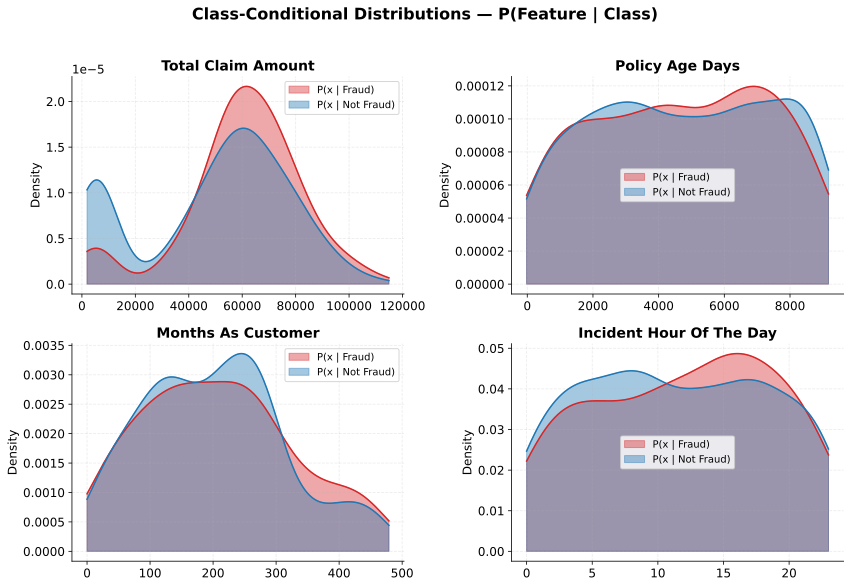

In [19]:
# ── FIGURE 1: Class-Conditional Densities ──
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12})
valid = [f for f in BAYESIAN_FEATURES if f in conditionals]
n = len(valid)
cols = 2
rows = (n + 1) // 2
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = np.array(axes).flatten()

for i, feat in enumerate(valid):
    ax = axes[i]
    c = conditionals[feat]
    ax.fill_between(c["x_range"], c["fraud_density"], alpha=0.4, color="#d62728", label="P(x | Fraud)")
    ax.fill_between(c["x_range"], c["legit_density"], alpha=0.4, color="#1f77b4", label="P(x | Not Fraud)")
    ax.plot(c["x_range"], c["fraud_density"], color="#d62728", linewidth=1.5)
    ax.plot(c["x_range"], c["legit_density"], color="#1f77b4", linewidth=1.5)
    ax.set_title(feat.replace("_", " ").title(), fontsize=14, fontweight="bold")
    ax.set_ylabel("Density", fontsize=12)
    ax.legend(fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.25, linestyle="--")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Class-Conditional Distributions — P(Feature | Class)", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
saver.save(fig, "class_conditional_densities")
plt.show()

### 6.2 Prior-to-Posterior Bayesian Update

**What:** Bar charts showing how $P(\text{fraud} \mid \mathbf{x})$ evolves as each feature is observed sequentially for 3 sample claims. Bars above 0.5 = fraud-leaning (red), below = legit-leaning (blue).

**Why it matters:** Demonstrates the interpretability of the Bayesian approach — stakeholders can see exactly which feature "tipped the scales" for a given claim. This transparency is critical for regulatory compliance.

**Variables used:** `update_traces`

  ✓ saved prior_posterior_update.pdf / .svg → /root/IX-Safety-Latex/code/../figures


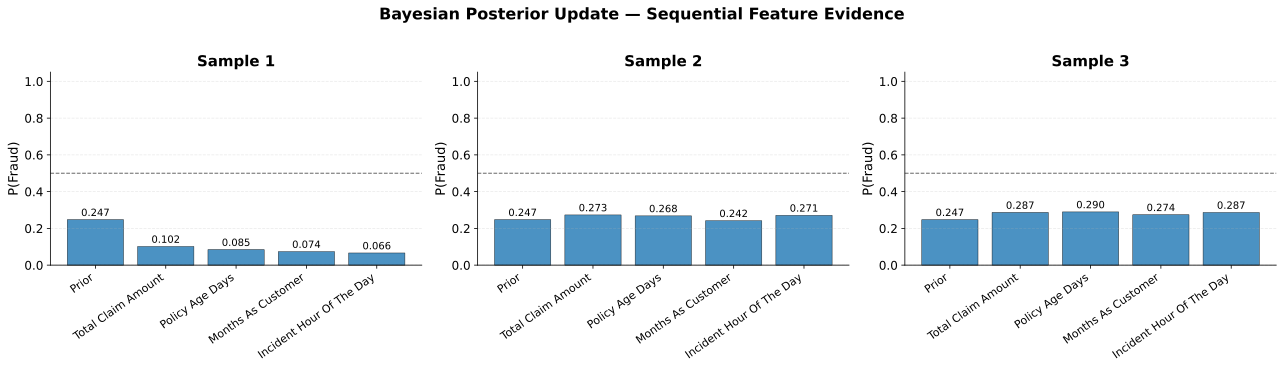

In [20]:
# ── FIGURE 2: Prior-to-Posterior Bayesian Update ──
fig, axes = plt.subplots(1, len(update_traces), figsize=(6 * len(update_traces), 5), squeeze=False)
axes = axes.flatten()

for idx, trace in enumerate(update_traces):
    ax = axes[idx]
    labels = [t["feature"].replace("_", " ").title() for t in trace]
    probs = [t["probability"] for t in trace]
    colors = ["#d62728" if p > 0.5 else "#1f77b4" for p in probs]

    bars = ax.bar(range(len(probs)), probs, color=colors, alpha=0.8, edgecolor="black", linewidth=0.5)
    ax.axhline(y=0.5, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=11)
    ax.set_ylabel("P(Fraud)", fontsize=13)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Sample {idx + 1}", fontsize=15, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linestyle="--")

    for bar, prob in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{prob:.3f}", ha="center", fontsize=10)

fig.suptitle("Bayesian Posterior Update — Sequential Feature Evidence", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
saver.save(fig, "prior_posterior_update")
plt.show()

---

#### Model Comparison (Figures 6.3-6.6)

---

### 6.3 ROC Curve Overlay

**What:** Receiver Operating Characteristic curves for all 6 classifiers, with AUC scores in the legend.

**Why it matters:** ROC curves show the **discrimination ability** of each model across all classification thresholds. A model that hugs the top-left corner (high AUC) can achieve high sensitivity without sacrificing specificity. XGBoost typically dominates here.

**Variables used:** `fitted_models`, `X_test`, `y_test`, `ADV_COLORS`

  ✓ saved roc_overlay.pdf / .svg → /root/IX-Safety-Latex/code/../figures


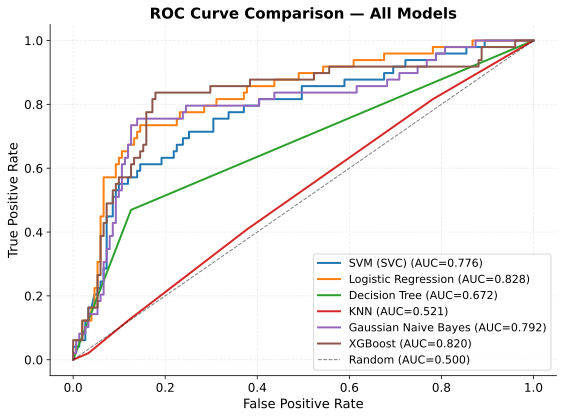

In [21]:
# ── FIGURE 3: ROC Curve Overlay ──
fig, ax = plt.subplots(figsize=(8, 6))
for (name, model), color in zip(fitted_models.items(), ADV_COLORS):
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={roc_auc_val:.3f})")
    except Exception:
        continue
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title("ROC Curve Comparison — All Models", fontsize=15, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.25, linestyle="--")
fig.tight_layout()
saver.save(fig, "roc_overlay")
plt.show()

### 6.4 Calibration Curves

**What:** Reliability diagrams plotting predicted probability vs observed frequency of fraud for each model.

**Why it matters:** A well-calibrated model (diagonal line) means "when it says 70% fraud, it really is fraud 70% of the time." This is essential for the deferral system because the confidence threshold $\tau_c = 0.65$ only makes sense if probabilities are well-calibrated. Models above the diagonal are **underconfident**; below are **overconfident**.

**Variables used:** `fitted_models`, `X_test`, `y_test`, `ADV_COLORS`

  ✓ saved calibration_curves.pdf / .svg → /root/IX-Safety-Latex/code/../figures


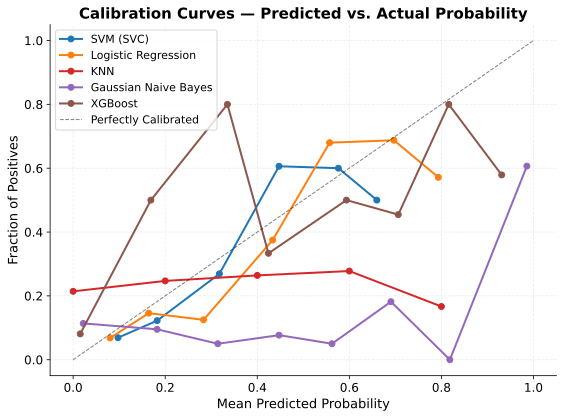

In [22]:
# ── FIGURE 4: Calibration Curves ──
fig, ax = plt.subplots(figsize=(8, 6))
for (name, model), color in zip(fitted_models.items(), ADV_COLORS):
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        if len(np.unique(y_proba)) < 3:
            continue
        prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=8)
        ax.plot(prob_pred, prob_true, "o-", color=color, linewidth=2, label=name)
    except Exception:
        continue
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Perfectly Calibrated")
ax.set_xlabel("Mean Predicted Probability", fontsize=13)
ax.set_ylabel("Fraction of Positives", fontsize=13)
ax.set_title("Calibration Curves — Predicted vs. Actual Probability", fontsize=15, fontweight="bold")
ax.legend(loc="upper left", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.25, linestyle="--")
fig.tight_layout()
saver.save(fig, "calibration_curves")
plt.show()

### 6.5 Cross-Validation Boxplot

**What:** Distribution of F1 scores across 5 stratified folds for each classifier. Box = IQR, whiskers = 1.5x IQR, annotations show mean +/- std.

**Why it matters:** A single train/test split can be misleading. CV reveals how **stable** each model's performance is across different data splits. Models with tight boxes and high medians are the most reliable choices for the base classifier.

**Variables used:** `cv_results`, `ADV_COLORS`

  ✓ saved cv_boxplot.pdf / .svg → /root/IX-Safety-Latex/code/../figures


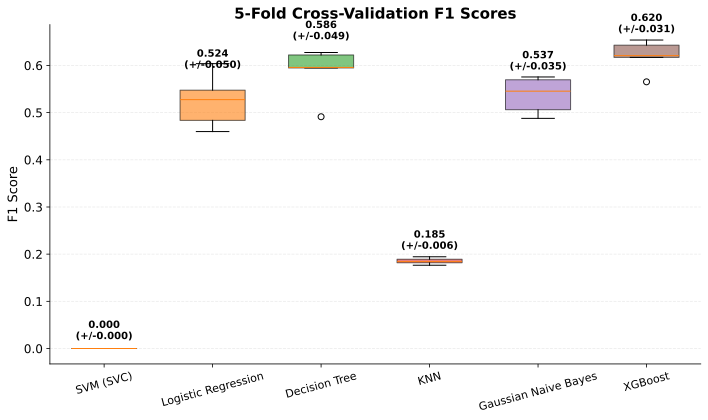

In [23]:
# ── FIGURE 5: CV Boxplot ──
model_names_cv = list(cv_results.keys())
f1_data = [cv_results[n]["f1_scores"] for n in model_names_cv]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(f1_data, labels=model_names_cv, patch_artist=True, widths=0.6)
for patch, color in zip(bp["boxes"], ADV_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for i, name in enumerate(model_names_cv):
    mean = cv_results[name]["f1_mean"]
    std = cv_results[name]["f1_std"]
    ax.text(i + 1, mean + std + 0.02, f"{mean:.3f}\n(+/-{std:.3f})",
            ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("F1 Score", fontsize=13)
ax.set_title("5-Fold Cross-Validation F1 Scores", fontsize=15, fontweight="bold")
ax.tick_params(axis="x", rotation=15, labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
fig.tight_layout()
saver.save(fig, "cv_boxplot")
plt.show()

### 6.6 McNemar's Test Heatmap

**What:** Matrix of p-values from pairwise McNemar's tests between all 6 classifiers. Green = no significant difference; red with * = significantly different error patterns ($p < 0.05$).

**Why it matters:** Two models can have similar accuracy but make **different mistakes**. McNemar's test detects this by comparing the off-diagonal entries of the 2x2 agreement table. If two models are significantly different, combining them (e.g., via deferral) can improve overall performance.

$$\chi^2 = \frac{(|b - c| - 1)^2}{b + c}$$

**Variables used:** `mcnemar_df`

  ✓ saved mcnemar_heatmap.pdf / .svg → /root/IX-Safety-Latex/code/../figures


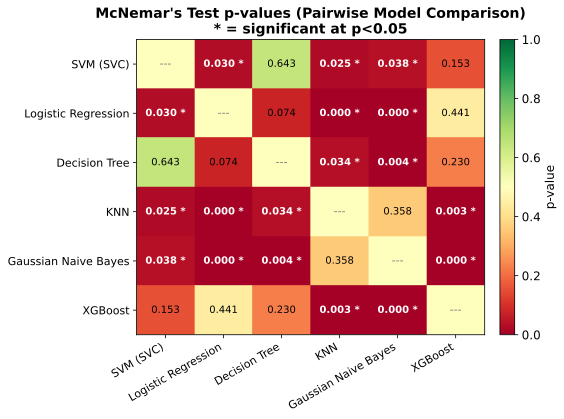

In [24]:
# ── FIGURE 6: McNemar Heatmap ──
fig, ax = plt.subplots(figsize=(8, 6))
data = mcnemar_df.values.copy()
mask = np.isnan(data)
display_data = np.where(mask, 0.5, data)

im = ax.imshow(display_data, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
n = len(mcnemar_df)
for i in range(n):
    for j in range(n):
        if i == j:
            ax.text(j, i, "---", ha="center", va="center", fontsize=11, color="gray")
        else:
            val = data[i, j]
            txt_color = "white" if val < 0.05 else "black"
            weight = "bold" if val < 0.05 else "normal"
            sig = " *" if val < 0.05 else ""
            ax.text(j, i, f"{val:.3f}{sig}", ha="center", va="center",
                    fontsize=10, color=txt_color, fontweight=weight)

names = list(mcnemar_df.columns)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(names, rotation=30, ha="right", fontsize=11)
ax.set_yticklabels(names, fontsize=11)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("p-value", fontsize=12)
ax.set_title("McNemar's Test p-values (Pairwise Model Comparison)\n* = significant at p<0.05",
             fontsize=14, fontweight="bold")
fig.tight_layout()
saver.save(fig, "mcnemar_heatmap")
plt.show()

---

#### Causal Analysis (Figures 6.7-6.9)

---

### 6.7 Causal DAG

**What:** Directed Acyclic Graph encoding hypothesised causal relationships between insurance claim features and fraud. Layered layout from background variables (top) to the fraud outcome (bottom, red).

**Why it matters:** The DAG justifies our feature selection by identifying which variables are **causes** vs **confounders** vs **colliders**. It also reveals which paths from features to fraud are causal (direct arrows) vs spurious (backdoor paths that need adjustment).

**Variables used:** `dag` (from `build_causal_dag()`)

  ✓ saved causal_dag.pdf / .svg → /root/IX-Safety-Latex/code/../figures


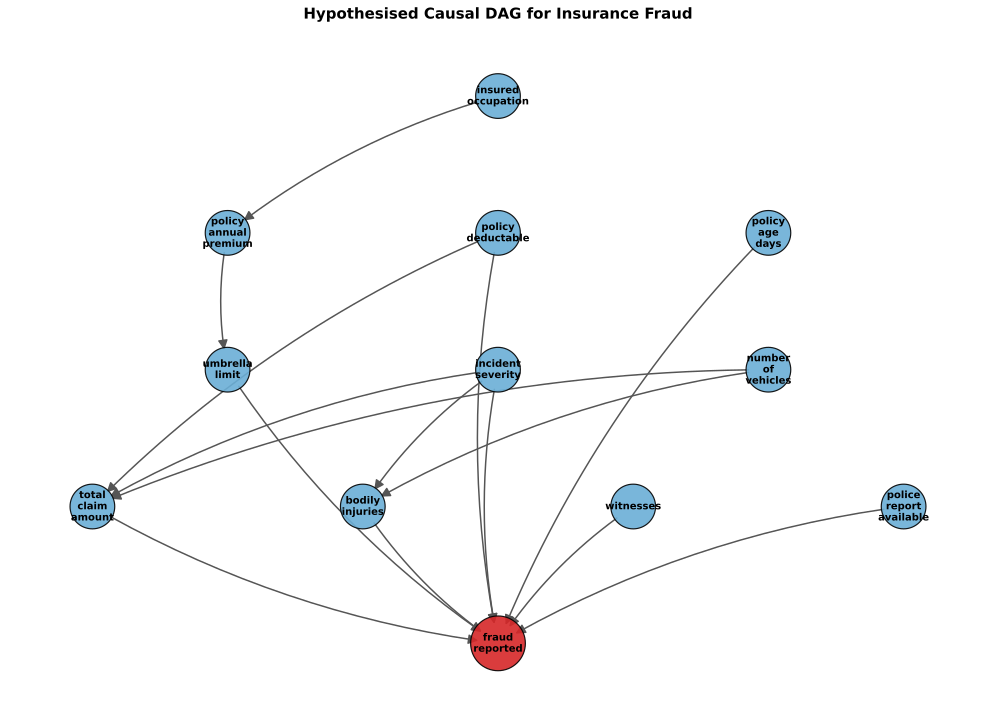

In [25]:
# ── FIGURE 7: Causal DAG ──
layers = {
    0: ["insured_occupation"],
    1: ["policy_annual_premium", "policy_deductable", "policy_age_days"],
    2: ["umbrella_limit", "incident_severity", "number_of_vehicles"],
    3: ["total_claim_amount", "bodily_injuries", "witnesses", "police_report_available"],
    4: ["fraud_reported"],
}
pos = {}
for layer_idx, nodes in layers.items():
    y = 1.0 - layer_idx * 0.22
    n_nodes = len(nodes)
    for i, node in enumerate(nodes):
        x = (i - (n_nodes - 1) / 2) * 0.28
        pos[node] = (x, y)

fig, ax = plt.subplots(figsize=(14, 10))
node_colors = ["#d62728" if n == "fraud_reported" else "#6baed6" for n in dag.nodes()]
node_sizes = [3000 if n == "fraud_reported" else 2000 for n in dag.nodes()]

nx.draw_networkx_nodes(dag, pos, ax=ax, node_color=node_colors,
                       node_size=node_sizes, alpha=0.9, edgecolors="black", linewidths=1.2)
nx.draw_networkx_edges(dag, pos, ax=ax, edge_color="#555555", arrows=True,
                       arrowsize=20, width=1.5, connectionstyle="arc3,rad=0.1",
                       min_source_margin=20, min_target_margin=20)
labels = {n: n.replace("_", "\n") for n in dag.nodes()}
nx.draw_networkx_labels(dag, pos, labels=labels, ax=ax, font_size=10, font_weight="bold")

ax.set_title("Hypothesised Causal DAG for Insurance Fraud", fontsize=15, fontweight="bold", pad=20)
ax.axis("off")
fig.tight_layout()
saver.save(fig, "causal_dag")
plt.show()

### 6.8 Propensity Score Analysis

**What:** *Left panel:* Distribution of propensity scores $e(\mathbf{x}) = P(\text{police report} \mid \mathbf{x})$ for treatment (report=YES) vs control (report=NO) groups. *Right panel:* Stratum-level average treatment effects with the overall ATE shown as a dashed line.

**Why it matters:** If the propensity score distributions have good **overlap** (common support), we can credibly estimate the causal effect of police reports on fraud detection. The stratum-level effects show whether this effect is consistent or heterogeneous across the population.

**Variables used:** `ps_results`

  ✓ saved propensity_scores.pdf / .svg → /root/IX-Safety-Latex/code/../figures


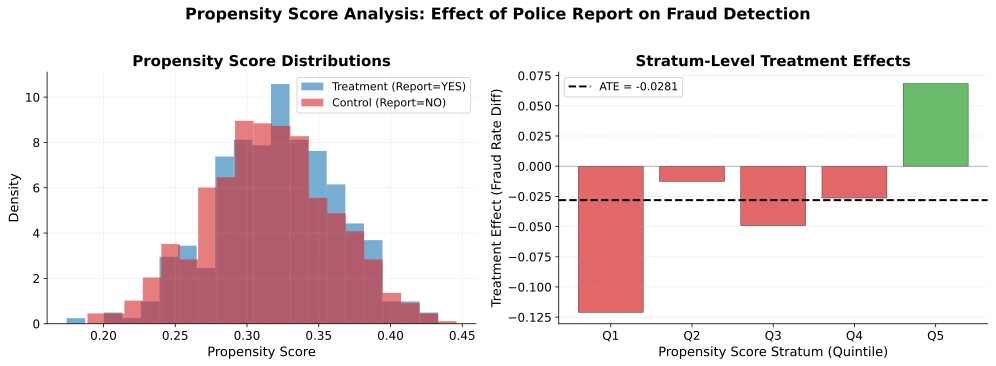

In [26]:
# ── FIGURE 8: Propensity Scores ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ps = ps_results["propensity_scores"]
treatment = ps_results["treatment"]

ax1.hist(ps[treatment == 1], bins=20, alpha=0.6, color="#1f77b4", label="Treatment (Report=YES)", density=True)
ax1.hist(ps[treatment == 0], bins=20, alpha=0.6, color="#d62728", label="Control (Report=NO)", density=True)
ax1.set_xlabel("Propensity Score", fontsize=13)
ax1.set_ylabel("Density", fontsize=13)
ax1.set_title("Propensity Score Distributions", fontsize=15, fontweight="bold")
ax1.legend(fontsize=11)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(alpha=0.25, linestyle="--")

effects = ps_results["stratum_effects"]
ate = ps_results["ate"]
x_pos = range(len(effects))
colors_ps = ["#2ca02c" if e > 0 else "#d62728" for e in effects]
ax2.bar(x_pos, effects, color=colors_ps, alpha=0.7, edgecolor="black", linewidth=0.5)
ax2.axhline(y=ate, color="black", linestyle="--", linewidth=2, label=f"ATE = {ate:.4f}")
ax2.axhline(y=0, color="gray", linestyle="-", linewidth=0.5)
ax2.set_xlabel("Propensity Score Stratum (Quintile)", fontsize=13)
ax2.set_ylabel("Treatment Effect (Fraud Rate Diff)", fontsize=13)
ax2.set_title("Stratum-Level Treatment Effects", fontsize=15, fontweight="bold")
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"Q{i+1}" for i in x_pos])
ax2.legend(fontsize=11)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(axis="y", alpha=0.25, linestyle="--")

fig.suptitle("Propensity Score Analysis: Effect of Police Report on Fraud Detection",
             fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
saver.save(fig, "propensity_scores")
plt.show()

### 6.9 Feature Importance Comparison

**What:** *Left panel:* Permutation importance from Logistic Regression (how much F1 drops when a feature is shuffled). *Right panel:* KL divergence between fraud/legit class-conditional densities for Bayesian features.

**Why it matters:** These two views represent the **discriminative** (permutation) and **generative** (Bayesian KDE) perspectives on feature importance. Features that rank highly in both are the most robust predictors of fraud and the strongest signals for the deferral system.

**Variables used:** `importance_df`

  ✓ saved feature_importance_comparison.pdf / .svg → /root/IX-Safety-Latex/code/../figures


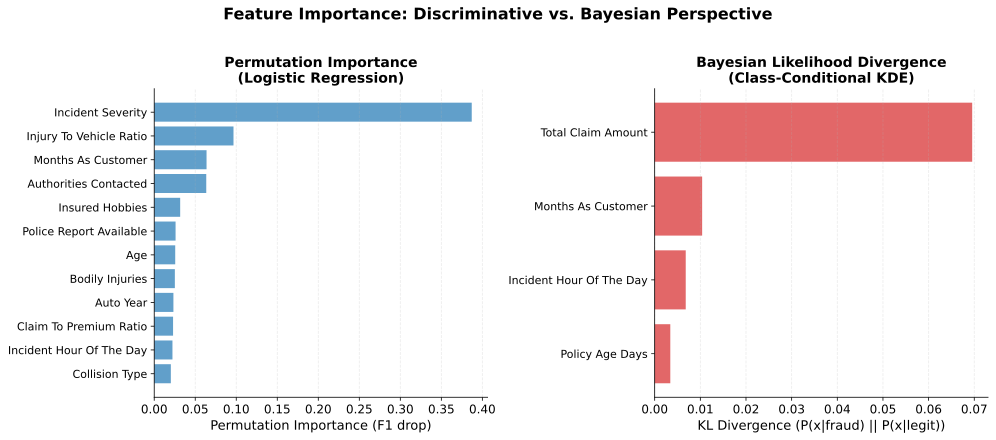

In [27]:
# ── FIGURE 9: Feature Importance Comparison ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

top_perm = importance_df.dropna(subset=["perm_importance"]).nlargest(12, "perm_importance")
ax1.barh(range(len(top_perm)), top_perm["perm_importance"].values, color="#1f77b4", alpha=0.7)
ax1.set_yticks(range(len(top_perm)))
ax1.set_yticklabels([f.replace("_", " ").title() for f in top_perm["feature"]], fontsize=11)
ax1.invert_yaxis()
ax1.set_xlabel("Permutation Importance (F1 drop)", fontsize=13)
ax1.set_title("Permutation Importance\n(Logistic Regression)", fontsize=14, fontweight="bold")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(axis="x", alpha=0.25, linestyle="--")

kl_data = importance_df.dropna(subset=["kl_divergence"]).sort_values("kl_divergence", ascending=False)
if len(kl_data) > 0:
    ax2.barh(range(len(kl_data)), kl_data["kl_divergence"].values, color="#d62728", alpha=0.7)
    ax2.set_yticks(range(len(kl_data)))
    ax2.set_yticklabels([f.replace("_", " ").title() for f in kl_data["feature"]], fontsize=11)
    ax2.invert_yaxis()
ax2.set_xlabel("KL Divergence (P(x|fraud) || P(x|legit))", fontsize=13)
ax2.set_title("Bayesian Likelihood Divergence\n(Class-Conditional KDE)", fontsize=14, fontweight="bold")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(axis="x", alpha=0.25, linestyle="--")

fig.suptitle("Feature Importance: Discriminative vs. Bayesian Perspective",
             fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
saver.save(fig, "feature_importance_comparison")
plt.show()

---

#### L2D System (Figures 6.10-6.12)

---

### 6.10 L2D System Architecture Diagram

**What:** Flow diagram of the Safe-L2D-Fraud pipeline: claim input -> XGBoost classifier + Bayesian uncertainty + CVaR monitor -> deferral gate -> auto-flag / auto-clear / defer to investigator.

**Why it matters:** This is the **key diagram** for the paper and presentation. It visually communicates the entire system architecture in one figure. Each box represents a component with its mathematical notation.

**Variables used:** None (diagram created from scratch)

  ✓ saved l2d_system_diagram.pdf / .svg → /root/IX-Safety-Latex/code/../figures


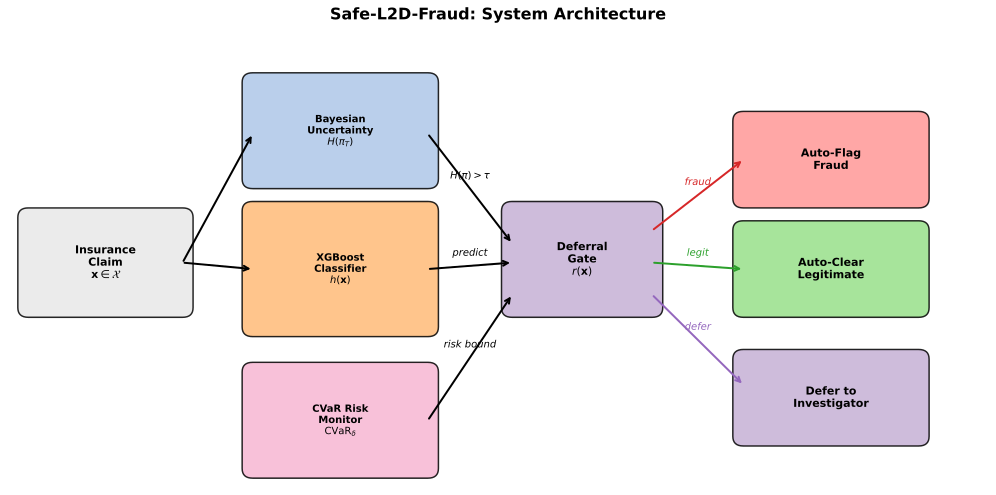

In [28]:
# ── FIGURE 10: L2D System Diagram ──
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis("off")

def draw_box(x, y, w, h, text, color, fontsize=11):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.15",
                          facecolor=color, edgecolor="black", linewidth=1.5, alpha=0.85)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center",
            fontsize=fontsize, fontweight="bold", wrap=True)

def draw_arrow(x1, y1, x2, y2, text="", color="black"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color=color, lw=2))
    if text:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my + 0.2, text, ha="center", va="center", fontsize=10,
                fontstyle="italic", color=color)

draw_box(0.3, 2.8, 2.2, 1.4, "Insurance\nClaim\n$\\mathbf{x} \\in \\mathcal{X}$", "#e8e8e8", 11)
draw_box(3.5, 4.8, 2.5, 1.5, "Bayesian\nUncertainty\n$H(\\pi_T)$", "#aec7e8", 10)
draw_box(3.5, 2.5, 2.5, 1.8, "XGBoost\nClassifier\n$h(\\mathbf{x})$", "#ffbb78", 10)
draw_box(3.5, 0.3, 2.5, 1.5, "CVaR Risk\nMonitor\n$\\text{CVaR}_\\delta$", "#f7b6d2", 10)
draw_box(7.2, 2.8, 2.0, 1.5, "Deferral\nGate\n$r(\\mathbf{x})$", "#c5b0d5", 11)
draw_box(10.5, 4.5, 2.5, 1.2, "Auto-Flag\nFraud", "#ff9896", 11)
draw_box(10.5, 2.8, 2.5, 1.2, "Auto-Clear\nLegitimate", "#98df8a", 11)
draw_box(10.5, 0.8, 2.5, 1.2, "Defer to\nInvestigator", "#c5b0d5", 11)

draw_arrow(2.5, 3.5, 3.5, 3.4, "")
draw_arrow(2.5, 3.5, 3.5, 5.5, "")
draw_arrow(6.0, 5.5, 7.2, 3.8, "$H(\\pi) > \\tau$")
draw_arrow(6.0, 3.4, 7.2, 3.5, "predict")
draw_arrow(6.0, 1.05, 7.2, 3.0, "risk bound")
draw_arrow(9.2, 4.0, 10.5, 5.1, "fraud", "#d62728")
draw_arrow(9.2, 3.5, 10.5, 3.4, "legit", "#2ca02c")
draw_arrow(9.2, 3.0, 10.5, 1.6, "defer", "#9467bd")

fig.suptitle("Safe-L2D-Fraud: System Architecture", fontsize=16, fontweight="bold", y=0.98)
fig.tight_layout()
saver.save(fig, "l2d_system_diagram")
plt.show()

### 6.11 Coverage-Accuracy Tradeoff

**What:** The **primary results figure**. Two panels showing system accuracy (left) and F1 (right) as functions of coverage (fraction of claims the classifier handles vs defers). Four curves: Safe-L2D, L2D without CVaR, confidence-only baseline, and standalone XGBoost (single point at coverage=1.0).

**Why it matters:** This directly demonstrates the **value of deferral**: as coverage decreases (more claims deferred), accuracy improves because the hardest cases go to the expert. The gap between Safe-L2D and the confidence baseline shows the benefit of Bayesian entropy; the gap with "no CVaR" shows the benefit of tail-risk control.

**Variables used:** `results_dict`, `_smooth`

  ✓ saved coverage_accuracy_tradeoff.pdf / .svg → /root/IX-Safety-Latex/code/../figures


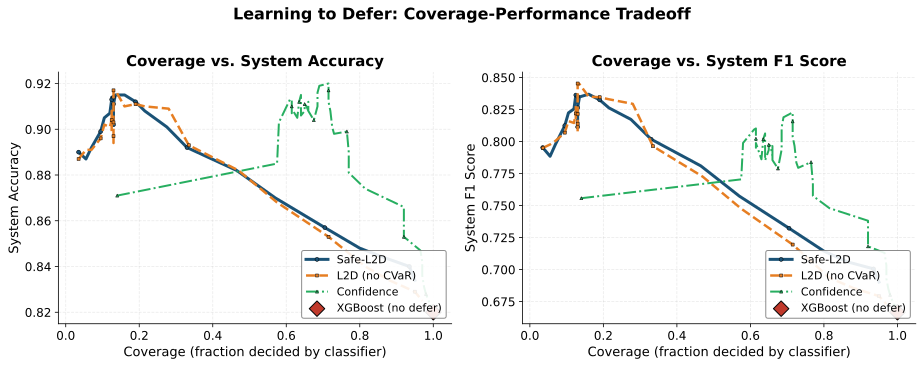

In [29]:
# ── FIGURE 11: Coverage-Accuracy Tradeoff ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

style_map = {
    "Safe-L2D": {"color": "#1a5276", "ls": "-", "lw": 3.0, "marker": "o", "ms": 4},
    "L2D (no CVaR)": {"color": "#e67e22", "ls": "--", "lw": 2.5, "marker": "s", "ms": 3},
    "Confidence": {"color": "#27ae60", "ls": "-.", "lw": 2.0, "marker": "^", "ms": 3},
    "XGBoost": {"color": "#c0392b", "ls": ":", "lw": 2.5, "marker": "D", "ms": 5},
}

for name, res in results_dict.items():
    st = style_map.get(name, {"color": "#333", "ls": "-", "lw": 2, "marker": "", "ms": 0})
    if name == "XGBoost":
        for ax, metric in [(ax1, "accuracies"), (ax2, "f1s")]:
            ax.scatter([1.0], [res[metric][0]], color=st["color"], s=120,
                       marker=st["marker"], zorder=5, edgecolors="black", linewidths=1.0,
                       label=f"{name} (no defer)")
    else:
        for ax, metric in [(ax1, "accuracies"), (ax2, "f1s")]:
            xs, ys = _smooth(res["coverages"], res[metric], window=5)
            ax.plot(xs, ys, color=st["color"], linestyle=st["ls"],
                    linewidth=st["lw"], label=name, marker=st["marker"],
                    markevery=max(1, len(xs)//8), markersize=st["ms"],
                    markeredgecolor="black", markeredgewidth=0.5)

for ax, metric_name in [(ax1, "System Accuracy"), (ax2, "System F1 Score")]:
    ax.set_xlabel("Coverage (fraction decided by classifier)", fontsize=13)
    ax.set_ylabel(metric_name, fontsize=13)
    ax.set_title(f"Coverage vs. {metric_name}", fontsize=15, fontweight="bold")
    ax.legend(fontsize=11, loc="lower right", framealpha=0.9, edgecolor="gray")
    ax.grid(alpha=0.25, linestyle="--")
    ax.set_xlim(-0.02, 1.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Learning to Defer: Coverage-Performance Tradeoff", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
saver.save(fig, "coverage_accuracy_tradeoff")
plt.show()

### 6.12 CVaR Deferral Analysis

**What:** *Left panel:* CVaR (tail risk) at $\delta \in \{0.05, 0.10, 0.20\}$ plotted against coverage. *Right panel:* Deferral rate broken down by Bayesian posterior probability bracket.

**Why it matters:** The left panel shows that tail risk **increases sharply** as coverage approaches 1.0 (no deferral), justifying the CVaR penalty. The right panel confirms that the system preferentially defers claims with **ambiguous posteriors** (near 0.5), which is exactly the intended behaviour.

**Variables used:** `system`, `X_test`, `y_test`, `posteriors`, `defer_mask`, `empirical_cvar`

  ✓ saved cvar_deferral_analysis.pdf / .svg → /root/IX-Safety-Latex/code/../figures


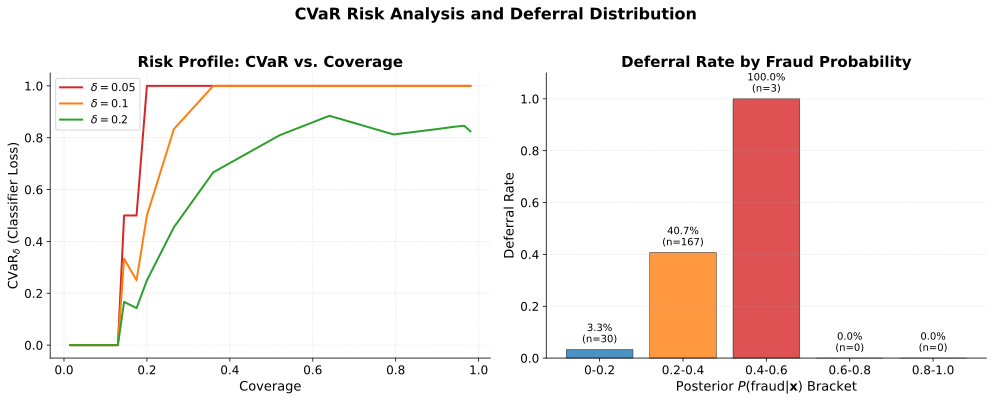

In [30]:
# ── FIGURE 12: CVaR Deferral Analysis ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: CVaR at different delta values across coverage
deltas = [0.05, 0.10, 0.20]
delta_colors = ["#d62728", "#ff7f0e", "#2ca02c"]
proba_cvar = system.calibrated_model.predict_proba(X_test)
pred_class_cvar = np.argmax(proba_cvar, axis=1)
conf_cvar = np.max(proba_cvar, axis=1)
ent_cvar, _ = system.uncertainty.compute_all_entropies(X_test)

for delta, dc in zip(deltas, delta_colors):
    thresholds = np.linspace(0.0, 1.0, 40)
    cvars_at_delta, coverages_cvar = [], []
    for thresh in thresholds:
        dm = (ent_cvar > thresh) | (conf_cvar < 0.55)
        nd = ~dm
        coverages_cvar.append(nd.sum() / len(y_arr))
        if nd.sum() == 0:
            cvars_at_delta.append(np.nan)
            continue
        losses = (pred_class_cvar[nd] != y_arr[nd]).astype(float)
        cvars_at_delta.append(empirical_cvar(losses, delta))
    ax1.plot(coverages_cvar, cvars_at_delta, linewidth=2, color=dc, label=f"$\\delta={delta}$")

ax1.set_xlabel("Coverage", fontsize=13)
ax1.set_ylabel("$\\mathrm{CVaR}_\\delta$ (Classifier Loss)", fontsize=13)
ax1.set_title("Risk Profile: CVaR vs. Coverage", fontsize=15, fontweight="bold")
ax1.legend(fontsize=11)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(alpha=0.25, linestyle="--")

# Right: Deferral rate by posterior probability bracket
brackets = [(0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.0)]
bracket_labels = ["0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]
deferral_rates_br, bracket_counts_br = [], []
for lo, hi in brackets:
    mask_br = (posteriors >= lo) & (posteriors < hi)
    if mask_br.sum() == 0:
        deferral_rates_br.append(0); bracket_counts_br.append(0); continue
    deferral_rates_br.append(defer_mask[mask_br].mean())
    bracket_counts_br.append(mask_br.sum())

bar_colors_br = ["#1f77b4", "#ff7f0e", "#d62728", "#ff7f0e", "#1f77b4"]
bars = ax2.bar(range(len(brackets)), deferral_rates_br, color=bar_colors_br, alpha=0.8, edgecolor="black", linewidth=0.5)
for i, (rate, count) in enumerate(zip(deferral_rates_br, bracket_counts_br)):
    ax2.text(i, rate + 0.02, f"{rate:.1%}\n(n={count})", ha="center", va="bottom", fontsize=10)

ax2.set_xticks(range(len(brackets)))
ax2.set_xticklabels(bracket_labels)
ax2.set_xlabel("Posterior $P(\\mathrm{fraud} | \\mathbf{x})$ Bracket", fontsize=13)
ax2.set_ylabel("Deferral Rate", fontsize=13)
ax2.set_title("Deferral Rate by Fraud Probability", fontsize=15, fontweight="bold")
ax2.set_ylim(0, 1.1)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(axis="y", alpha=0.25, linestyle="--")

fig.suptitle("CVaR Risk Analysis and Deferral Distribution", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
saver.save(fig, "cvar_deferral_analysis")
plt.show()

---

#### Deferral & OPE (Figures 6.13-6.15)

---

### 6.13 Bayesian Deferral Entropy

**What:** Scatter plots of posterior entropy $H(\pi_T)$ vs classifier confidence $\max_i p_i$ for all test claims. *Left panel:* coloured by **true label** (fraud=red, legit=blue). *Right panel:* coloured by **deferral decision** (system=green, deferred=purple triangles). Vertical dashed line = entropy threshold $\tau$.

**Why it matters:** This is the "decision landscape" of the system. Claims in the high-entropy / low-confidence quadrant get deferred. The left panel shows that fraud cases cluster at higher entropy (harder to classify), validating the Bayesian signal.

**Variables used:** `entropies`, `confidence`, `defer_mask`, `y_arr`

  ✓ saved bayesian_deferral_entropy.pdf / .svg → /root/IX-Safety-Latex/code/../figures


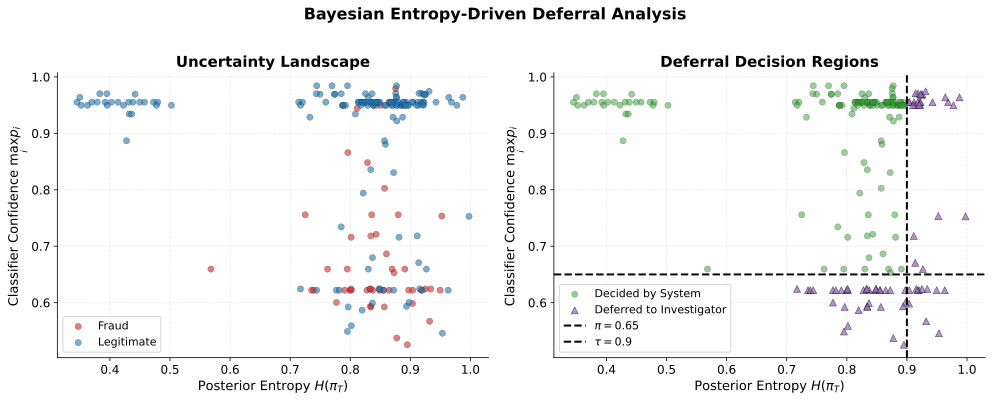

In [31]:
# ── FIGURE 13: Bayesian Deferral Entropy ──
entropy_threshold = 0.9
confidence_threshold = 0.65
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fraud_mask = y_arr == 1

# Left: entropy vs confidence coloured by true label
ax1.scatter(entropies[fraud_mask], confidence[fraud_mask],
            c="#d62728", alpha=0.6, s=40, label="Fraud", edgecolors="black", linewidth=0.3)
ax1.scatter(entropies[~fraud_mask], confidence[~fraud_mask],
            c="#1f77b4", alpha=0.6, s=40, label="Legitimate", edgecolors="black", linewidth=0.3)
# ax1.axvline(x=entropy_threshold, color="black", linestyle="--", linewidth=2,
#             label=f"$\\tau = {entropy_threshold}$")
ax1.set_xlabel("Posterior Entropy $H(\\pi_T)$", fontsize=13)
ax1.set_ylabel("Classifier Confidence $\\max_i p_i$", fontsize=13)
ax1.set_title("Uncertainty Landscape", fontsize=15, fontweight="bold")
ax1.legend(fontsize=11)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(alpha=0.25, linestyle="--")

# Right: entropy vs confidence coloured by deferral decision
ax2.scatter(entropies[~defer_mask], confidence[~defer_mask],
            c="#2ca02c", alpha=0.5, s=40, label="Decided by System", edgecolors="black", linewidth=0.3)
ax2.scatter(entropies[defer_mask], confidence[defer_mask],
            c="#9467bd", alpha=0.7, s=50, label="Deferred to Investigator",
            edgecolors="black", linewidth=0.5, marker="^")
ax2.axhline(y=confidence_threshold, color="black", linestyle="--", linewidth=2,
            label=f"$\\pi = {confidence_threshold}$")
ax2.axvline(x=entropy_threshold, color="black", linestyle="--", linewidth=2,
            label=f"$\\tau = {entropy_threshold}$")
ax2.set_xlabel("Posterior Entropy $H(\\pi_T)$", fontsize=13)
ax2.set_ylabel("Classifier Confidence $\\max_i p_i$", fontsize=13)
ax2.set_title("Deferral Decision Regions", fontsize=15, fontweight="bold")
ax2.legend(fontsize=11)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(alpha=0.25, linestyle="--")

fig.suptitle("Bayesian Entropy-Driven Deferral Analysis", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
saver.save(fig, "bayesian_deferral_entropy")
plt.show()

### 6.14 OPE Estimators Comparison

**What:** Grouped bar chart comparing three Off-Policy Evaluation estimators (Direct Method, Importance Sampling/SNIPS, Doubly Robust) across three policies (Safe-L2D, XGBoost, Random). Error bars show 95% bootstrap CIs.

**Why it matters:** Since we can't A/B test the deferral system in production, OPE provides the best available evidence that Safe-L2D outperforms baselines. Agreement across all three estimators (which have different bias-variance tradeoffs) strengthens the conclusion.

**Variables used:** `ope_results`

  ✓ saved ope_estimators_comparison.pdf / .svg → /root/IX-Safety-Latex/code/../figures


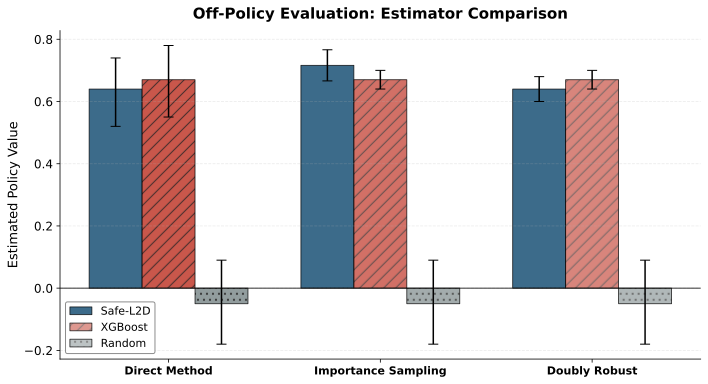

In [32]:
# ── FIGURE 14: OPE Estimators Comparison ──
fig, ax = plt.subplots(figsize=(10, 5.5))
methods = list(ope_results.keys())
x = np.arange(len(methods))
width = 0.25
policies = ["Safe-L2D", "XGBoost", "Random"]
policy_colors = ["#1a5276", "#c0392b", "#7f8c8d"]
hatches = ["", "//", ".."]

for j, (policy, color, hatch) in enumerate(zip(policies, policy_colors, hatches)):
    means, errors_low, errors_high = [], [], []
    for method in methods:
        entry = ope_results[method].get(policy, {})
        m = entry.get("mean", 0)
        lo = entry.get("ci_low", m)
        hi = entry.get("ci_high", m)
        means.append(m); errors_low.append(m - lo); errors_high.append(hi - m)
    ax.bar(x + j * width, means, width, label=policy, color=color, alpha=0.85,
           edgecolor="black", linewidth=0.8, hatch=hatch,
           yerr=[errors_low, errors_high], capsize=5, error_kw={"linewidth": 1.5})

ax.set_xticks(x + width)
ax.set_xticklabels([m.replace("\n", " ") for m in methods], fontsize=11, fontweight="bold")
ax.set_ylabel("Estimated Policy Value", fontsize=13)
ax.legend(fontsize=11, framealpha=0.9, edgecolor="gray")
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.axhline(y=0, color="black", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("Off-Policy Evaluation: Estimator Comparison", fontsize=15, fontweight="bold", pad=12)
fig.tight_layout()
saver.save(fig, "ope_estimators_comparison")
plt.show()

### 6.15 Ablation Study

**What:** Grouped bar chart comparing 4 system variants (Full Model, No CVaR, No Bayesian, No Deferral) on 4 metrics (Accuracy, F1, CVaR@0.10, Deferral Rate). Values annotated above each bar.

**Why it matters:** Quantifies each component's contribution. The key findings are:
- Removing Bayesian entropy degrades accuracy (loses uncertainty signal)
- Removing CVaR increases tail risk (less safe)
- Removing all deferral gives the worst CVaR (no safety net)

**Variables used:** `ablation_results`

  ✓ saved ablation_study.pdf / .svg → /root/IX-Safety-Latex/code/../figures


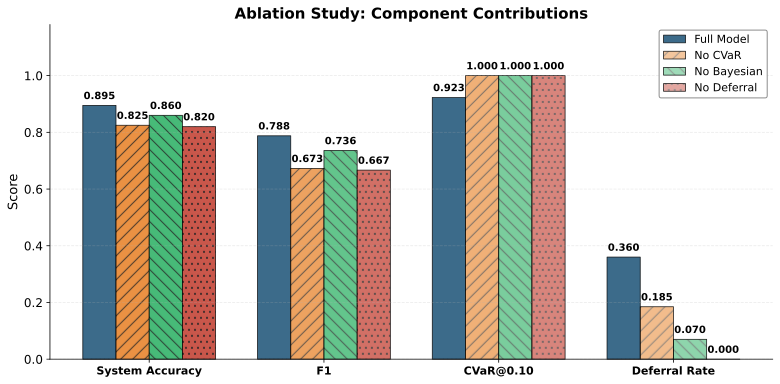

In [33]:
# ── FIGURE 15: Ablation Study ──
fig, ax = plt.subplots(figsize=(11, 5.5))
variants = list(ablation_results.keys())
metrics_abl = ["System Accuracy", "F1", "CVaR@0.10", "Deferral Rate"]
x = np.arange(len(metrics_abl))
width = 0.19
variant_colors = ["#1a5276", "#e67e22", "#27ae60", "#c0392b"]
hatches_abl = ["", "//", "\\\\", ".."]

for j, (variant, color, hatch) in enumerate(zip(variants, variant_colors, hatches_abl)):
    vals = [ablation_results[variant].get(m, 0) for m in metrics_abl]
    bars = ax.bar(x + j * width, vals, width, label=variant, color=color,
                  alpha=0.85, edgecolor="black", linewidth=0.8, hatch=hatch)
    for i, v in enumerate(vals):
        ax.text(x[i] + j * width, v + 0.015, f"{v:.3f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_abl, fontsize=11, fontweight="bold")
ax.set_ylabel("Score", fontsize=13)
ax.set_title("Ablation Study: Component Contributions", fontsize=15, fontweight="bold")
ax.legend(fontsize=11, loc="upper right", framealpha=0.9, edgecolor="gray")
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.set_ylim(0, 1.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
saver.save(fig, "ablation_study")
plt.show()

---

#### Robustness Analysis (Figures 6.16-6.18)

---

### 6.16 Bootstrap Confidence Intervals (B=2000)

**What:** Horizontal bar chart with 95% percentile bootstrap CIs for system accuracy (left) and F1 (right). Three systems compared: Safe-L2D, XGBoost standalone, and confidence-only baseline.

**Why it matters:** Point estimates are not enough for a safety-critical system. Bootstrap CIs show whether the performance differences are **statistically meaningful** or could be due to sampling variability. Non-overlapping CIs = strong evidence of real improvement.

**Variables used:** `boot_results`

  ✓ saved bootstrap_ci_results.pdf / .svg → /root/IX-Safety-Latex/code/../figures


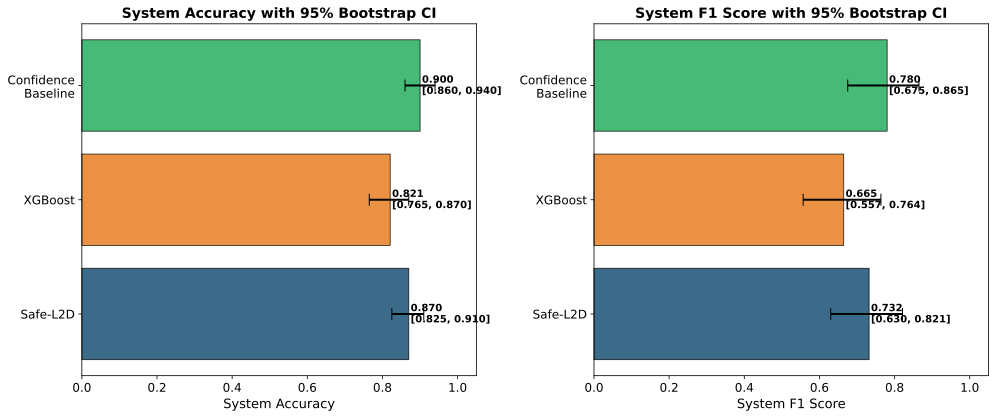

In [34]:
# ── FIGURE 16: Bootstrap CI Results ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
metrics_boot = ["accuracy", "f1"]
metric_labels_boot = ["System Accuracy", "System F1 Score"]

for ax, metric, label in zip(axes, metrics_boot, metric_labels_boot):
    names = list(boot_results.keys())
    means = [boot_results[n][metric]["mean"] for n in names]
    ci_lows = [boot_results[n][metric]["ci_low"] for n in names]
    ci_highs = [boot_results[n][metric]["ci_high"] for n in names]
    errors = [[m - lo for m, lo in zip(means, ci_lows)],
              [hi - m for m, hi in zip(means, ci_highs)]]

    colors_boot = ["#1a5276", "#e67e22", "#27ae60", "#c0392b"]
    y_pos = np.arange(len(names))
    bars = ax.barh(y_pos, means, xerr=errors, color=colors_boot[:len(names)],
                   alpha=0.85, edgecolor="black", linewidth=0.8,
                   capsize=6, error_kw={"linewidth": 2})

    for i, (m, lo, hi) in enumerate(zip(means, ci_lows, ci_highs)):
        ax.text(m + 0.005, i, f"{m:.3f}\n[{lo:.3f}, {hi:.3f}]",
                va="center", fontsize=10, fontweight="bold")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=12)
    ax.set_xlabel(label, fontsize=13)
    ax.set_title(f"{label} with 95% Bootstrap CI", fontsize=14, fontweight="bold")
    ax.set_xlim(0, 1.05)

fig.tight_layout()
saver.save(fig, "bootstrap_ci_results")
plt.show()

### 6.17 Investigator Sensitivity Analysis

**What:** System accuracy (left) and F1 (right) vs coverage, with separate curves for investigator accuracy $\alpha \in \{0.70, 0.80, 0.90, 0.95\}$.

**Why it matters:** Answers the question: "How good does the human expert need to be for L2D to work?" If even a mediocre investigator ($\alpha = 0.70$) improves the system, the deferral approach is robust. If only a near-perfect expert helps, the approach is fragile.

**Variables used:** `sensitivity_results`

  ✓ saved investigator_sensitivity.pdf / .svg → /root/IX-Safety-Latex/code/../figures


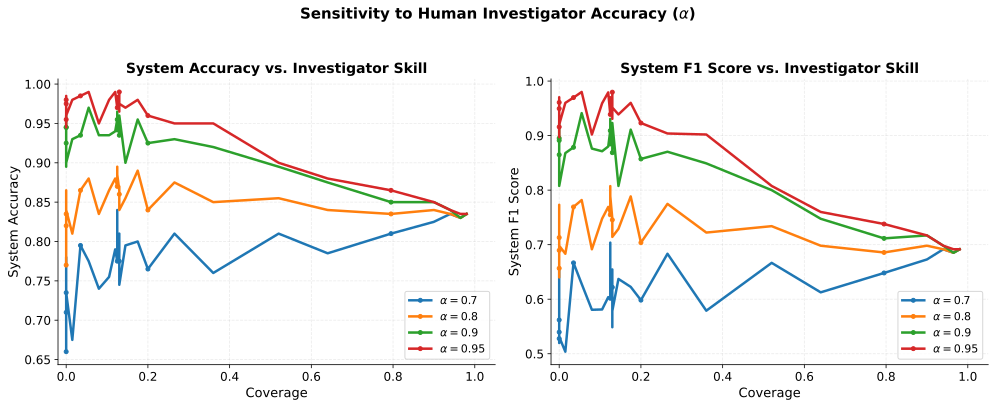

In [35]:
# ── FIGURE 17: Investigator Sensitivity ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
alphas = sorted(sensitivity_results.keys())

for ax, metric, label in [(ax1, "accuracy", "System Accuracy"),
                           (ax2, "f1", "System F1 Score")]:
    for alpha_val in alphas:
        res = sensitivity_results[alpha_val]
        ax.plot(res["coverages"], res[metric + "_vals"],
                linewidth=2.5, label=f"$\\alpha = {alpha_val}$",
                marker="o", markevery=max(1, len(res["coverages"]) // 8),
                markersize=4)
    ax.set_xlabel("Coverage", fontsize=13)
    ax.set_ylabel(label, fontsize=13)
    ax.set_title(f"{label} vs. Investigator Skill", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11, loc="lower right")
    ax.set_xlim(-0.02, 1.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.25, linestyle="--")

fig.suptitle("Sensitivity to Human Investigator Accuracy ($\\alpha$)",
             fontsize=15, fontweight="bold", y=1.03)
fig.tight_layout()
saver.save(fig, "investigator_sensitivity")
plt.show()

### 6.18 Spectral Risk Comparison

**What:** *Left panel:* Risk measure value vs coverage for CVaR, Wang transform, Dual-Power, and expected loss. *Right panel:* The distortion functions $g(u)$ themselves, showing how each one reweights the loss distribution.

**Why it matters:** CVaR is just one member of the spectral risk family. The Wang and Dual-Power distortions provide **smoother** alternatives that may be more appropriate depending on the regulator's risk preferences. The right panel gives intuition: curves above the diagonal overweight tail losses (risk-averse).

**Variables used:** `spectral_results`, `cvar_distortion`, `wang_distortion`, `dual_power_distortion`

  ✓ saved spectral_risk_comparison.pdf / .svg → /root/IX-Safety-Latex/code/../figures


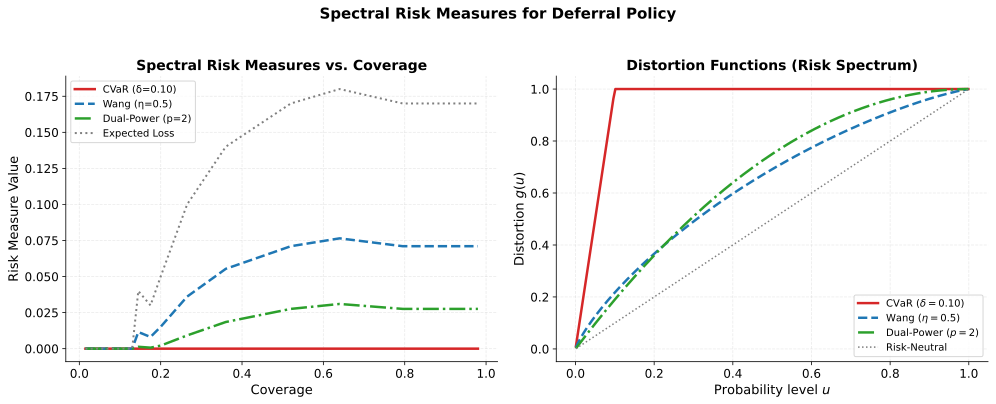

In [36]:
# ── FIGURE 18: Spectral Risk Comparison ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

risk_styles = {
    "CVaR (δ=0.10)": {"color": "#d62728", "ls": "-", "lw": 2.5},
    "Wang (η=0.5)": {"color": "#1f77b4", "ls": "--", "lw": 2.5},
    "Dual-Power (p=2)": {"color": "#2ca02c", "ls": "-.", "lw": 2.5},
    "Expected Loss": {"color": "#7f7f7f", "ls": ":", "lw": 2.0},
}

for name, data in spectral_results.items():
    st = risk_styles.get(name, {"color": "#333", "ls": "-", "lw": 2})
    ax1.plot(data["coverages"], data["risk_values"],
             color=st["color"], linestyle=st["ls"], linewidth=st["lw"], label=name)

ax1.set_xlabel("Coverage", fontsize=13)
ax1.set_ylabel("Risk Measure Value", fontsize=13)
ax1.set_title("Spectral Risk Measures vs. Coverage", fontsize=14, fontweight="bold")
ax1.legend(fontsize=10, loc="upper left")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(alpha=0.25, linestyle="--")

# Right: distortion functions
u = np.linspace(0.001, 0.999, 200)
ax2.plot(u, cvar_distortion(u, 0.10), color="#d62728", linewidth=2.5, label="CVaR ($\\delta=0.10$)")
ax2.plot(u, wang_distortion(u, 0.5), color="#1f77b4", linewidth=2.5, linestyle="--", label="Wang ($\\eta=0.5$)")
ax2.plot(u, dual_power_distortion(u, 2), color="#2ca02c", linewidth=2.5, linestyle="-.", label="Dual-Power ($p=2$)")
ax2.plot(u, u, color="#7f7f7f", linewidth=1.5, linestyle=":", label="Risk-Neutral")
ax2.set_xlabel("Probability level $u$", fontsize=13)
ax2.set_ylabel("Distortion $g(u)$", fontsize=13)
ax2.set_title("Distortion Functions (Risk Spectrum)", fontsize=14, fontweight="bold")
ax2.legend(fontsize=10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(alpha=0.25, linestyle="--")

fig.suptitle("Spectral Risk Measures for Deferral Policy", fontsize=15, fontweight="bold", y=1.03)
fig.tight_layout()
saver.save(fig, "spectral_risk_comparison")
plt.show()

---

#### Extended Analysis (Figures 6.19-6.21)

---

### 6.19 Cost-Sensitive Analysis

**What:** Grouped bar chart of normalised cost per claim under four asymmetric FN/FP cost ratios ($c_{FN}/c_{FP} \in \{1, 3, 5, 10\}$) for Safe-L2D, XGBoost, confidence baseline, and random policy.

**Why it matters:** In fraud detection, missing a fraud case (FN) is far more costly than a false alarm (FP). This figure shows that Safe-L2D's advantage **grows** as the cost asymmetry increases, because the deferral system sends uncertain (potentially fraudulent) cases to the expert rather than risking a costly miss.

**Variables used:** `cost_results`

  ✓ saved cost_sensitive_analysis.pdf / .svg → /root/IX-Safety-Latex/code/../figures


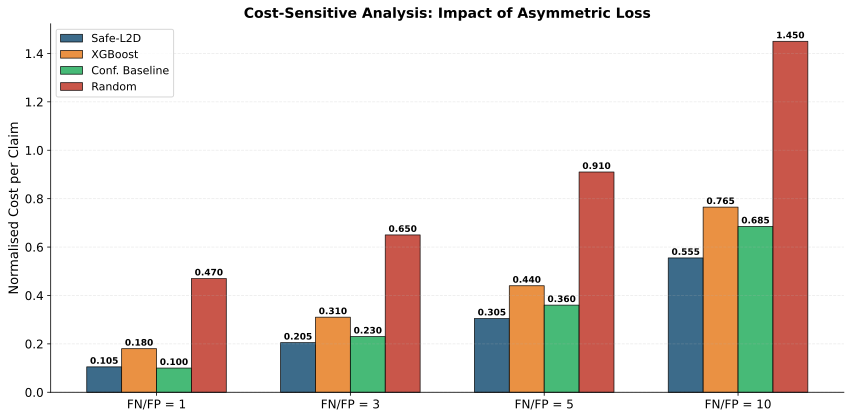

In [37]:
# ── FIGURE 19: Cost-Sensitive Analysis ──
fig, ax = plt.subplots(figsize=(12, 6))
ratios = sorted(cost_results.keys())
methods_cost = list(cost_results[ratios[0]].keys())
x = np.arange(len(ratios))
width = 0.18
method_colors = ["#1a5276", "#e67e22", "#27ae60", "#c0392b"]

for j, (method, color) in enumerate(zip(methods_cost, method_colors)):
    vals = [cost_results[r][method]["normalized_cost"] for r in ratios]
    bars = ax.bar(x + j * width, vals, width, label=method, color=color,
                  alpha=0.85, edgecolor="black", linewidth=0.8)
    for i, v in enumerate(vals):
        ax.text(x[i] + j * width, v + 0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"FN/FP = {r}" for r in ratios], fontsize=12)
ax.set_ylabel("Normalised Cost per Claim", fontsize=13)
ax.set_title("Cost-Sensitive Analysis: Impact of Asymmetric Loss",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25, linestyle="--")
fig.tight_layout()
saver.save(fig, "cost_sensitive_analysis")
plt.show()

### 6.20 Uncertainty Decomposition

**What:** *Left panel:* Epistemic (model) vs aleatoric (data) uncertainty for each test claim, coloured by true label. *Right panel:* Total uncertainty vs Bayesian posterior, coloured by deferral decision.

**Why it matters:** Epistemic uncertainty is **reducible** (more data or better models would help); aleatoric is **irreducible** (inherent randomness). Claims with high epistemic uncertainty are prime candidates for deferral — the expert may have domain knowledge the model lacks. Claims with high aleatoric uncertainty are genuinely ambiguous.

**Variables used:** `unc_data`, `defer_mask`, `y_arr`

  ✓ saved uncertainty_decomposition.pdf / .svg → /root/IX-Safety-Latex/code/../figures


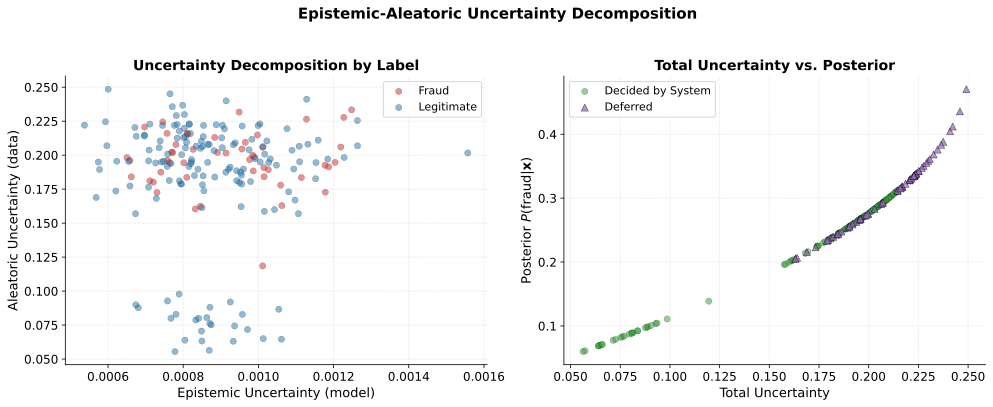

In [38]:
# ── FIGURE 20: Uncertainty Decomposition ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fraud_mask = y_arr == 1

# Left: epistemic vs aleatoric coloured by true label
ax1.scatter(unc_data["epistemic"][fraud_mask], unc_data["aleatoric"][fraud_mask],
            c="#d62728", alpha=0.5, s=40, label="Fraud", edgecolors="black", linewidths=0.3)
ax1.scatter(unc_data["epistemic"][~fraud_mask], unc_data["aleatoric"][~fraud_mask],
            c="#1f77b4", alpha=0.5, s=40, label="Legitimate", edgecolors="black", linewidths=0.3)
ax1.set_xlabel("Epistemic Uncertainty (model)", fontsize=13)
ax1.set_ylabel("Aleatoric Uncertainty (data)", fontsize=13)
ax1.set_title("Uncertainty Decomposition by Label", fontsize=14, fontweight="bold")
ax1.legend(fontsize=11)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(alpha=0.25, linestyle="--")

# Right: total uncertainty coloured by deferral decision
ax2.scatter(unc_data["total"][~defer_mask], unc_data["mean_posterior"][~defer_mask],
            c="#2ca02c", alpha=0.5, s=40, label="Decided by System", edgecolors="black", linewidths=0.3)
ax2.scatter(unc_data["total"][defer_mask], unc_data["mean_posterior"][defer_mask],
            c="#9467bd", alpha=0.7, s=50, label="Deferred", edgecolors="black", linewidths=0.5, marker="^")
ax2.set_xlabel("Total Uncertainty", fontsize=13)
ax2.set_ylabel("Posterior $P(\\mathrm{fraud} | \\mathbf{x})$", fontsize=13)
ax2.set_title("Total Uncertainty vs. Posterior", fontsize=14, fontweight="bold")
ax2.legend(fontsize=11)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(alpha=0.25, linestyle="--")

fig.suptitle("Epistemic-Aleatoric Uncertainty Decomposition", fontsize=15, fontweight="bold", y=1.03)
fig.tight_layout()
saver.save(fig, "uncertainty_decomposition")
plt.show()

### 6.21 Calibration-Aware Deferral

**What:** Reliability diagrams for **non-deferred claims** (left, green) vs **deferred claims** (right, purple). Each shows predicted probability vs observed frequency with Brier score annotated.

**Why it matters:** If the deferral system works correctly, non-deferred claims should be **better calibrated** (lower Brier score) because the system keeps only the cases it's confident about. Deferred claims should show worse calibration, confirming that the system correctly identifies cases where its probability estimates are unreliable.

**Variables used:** `system`, `X_test`, `y_arr`, `defer_mask`

---

*End of notebook.*

  ✓ saved calibration_deferral.pdf / .svg → /root/IX-Safety-Latex/code/../figures


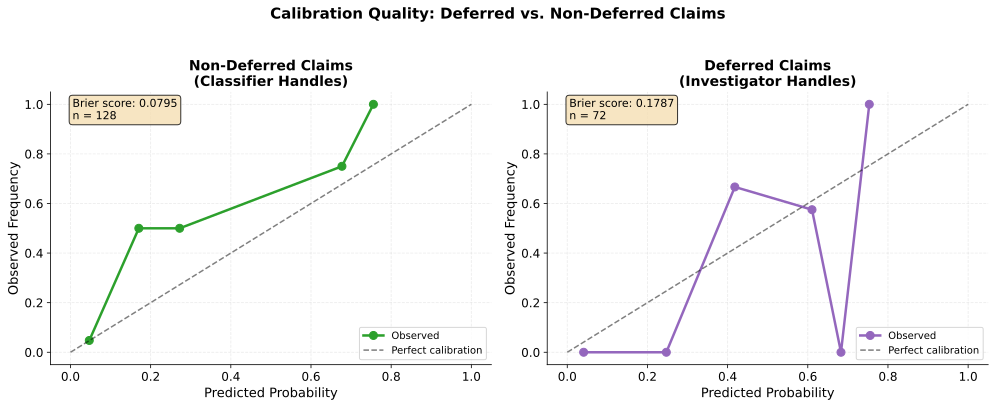

In [39]:
# ── FIGURE 21: Calibration-Aware Deferral ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
proba_cal = system.calibrated_model.predict_proba(X_test)[:, 1]

for ax, mask, title, color in [
    (ax1, ~defer_mask, "Non-Deferred Claims\n(Classifier Handles)", "#2ca02c"),
    (ax2, defer_mask, "Deferred Claims\n(Investigator Handles)", "#9467bd"),
]:
    if mask.sum() < 10:
        ax.text(0.5, 0.5, "Insufficient samples", ha="center", va="center",
                fontsize=14, transform=ax.transAxes)
        continue

    p_sub = proba_cal[mask]
    y_sub = y_arr[mask]

    try:
        prob_true, prob_pred = calibration_curve(y_sub, p_sub, n_bins=8)
        ax.plot(prob_pred, prob_true, "o-", color=color, linewidth=2.5, markersize=8, label="Observed")
        ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, alpha=0.5, label="Perfect calibration")
    except Exception:
        pass

    brier = brier_score_loss(y_sub, p_sub)
    ax.text(0.05, 0.90, f"Brier score: {brier:.4f}\nn = {mask.sum()}",
            transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    ax.set_xlabel("Predicted Probability", fontsize=13)
    ax.set_ylabel("Observed Frequency", fontsize=13)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.25, linestyle="--")

fig.suptitle("Calibration Quality: Deferred vs. Non-Deferred Claims",
             fontsize=15, fontweight="bold", y=1.03)
fig.tight_layout()
saver.save(fig, "calibration_deferral")
plt.show()